In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset

data=pd.read_csv('Microsoft Sample Data.csv')

In [3]:
data.head()

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,472446405890,62,488453,1418245,2024-06-15 01:47:48+00:00,5,39,SuspiciousActivity,NaN,2.0,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1,1374389537640,75,56,936055,2024-06-11 17:38:44+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,...,NaN,NaN,5,66,NaN,NaN,NaN,1,0,0
2,111669154679,37,34,8343,2024-06-06 15:44:59+00:00,70,4685,Exfiltration,NaN,0.0,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
3,1460288882818,90,157,869683,2024-06-04 18:53:10+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
4,1185410975439,70,14681,48583,2024-06-06 09:22:42+00:00,1,1,InitialAccess,T1566.002,1.0,...,NaN,NaN,5,66,NaN,NaN,Malicious,242,1445,10630


In [4]:
data['EmailClusterId'].value_counts()

4.023350e+09    107
4.218787e+09    105
4.140628e+09     82
2.122467e+09     38
2.834093e+09     37
               ... 
3.866163e+09      1
4.022589e+09      1
4.233327e+09      1
2.028244e+08      1
4.274976e+09      1
Name: EmailClusterId, Length: 3190, dtype: int64

In [5]:
data.set_index('Id',inplace=True)

In [6]:
print('The number of rows are ',data.shape[0])
print('The number of columns are ',data.shape[1])

The number of rows are  500000
The number of columns are  44


In [7]:
# Get information about data types and missing values
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500000 entries, 472446405890 to 635655164240
Data columns (total 44 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   OrgId               500000 non-null  int64  
 1   IncidentId          500000 non-null  int64  
 2   AlertId             500000 non-null  int64  
 3   Timestamp           500000 non-null  object 
 4   DetectorId          500000 non-null  int64  
 5   AlertTitle          500000 non-null  int64  
 6   Category            500000 non-null  object 
 7   MitreTechniques     212415 non-null  object 
 8   IncidentGrade       497280 non-null  float64
 9   ActionGrouped       2973 non-null    object 
 10  ActionGranular      2973 non-null    object 
 11  EntityType          500000 non-null  object 
 12  EvidenceRole        500000 non-null  object 
 13  DeviceId            500000 non-null  int64  
 14  Sha256              500000 non-null  int64  
 15  IpAddress        

In [8]:
# Check for missing values
data.isnull().mean()*100

OrgId                  0.0000
IncidentId             0.0000
AlertId                0.0000
Timestamp              0.0000
DetectorId             0.0000
AlertTitle             0.0000
Category               0.0000
MitreTechniques       57.5170
IncidentGrade          0.5440
ActionGrouped         99.4054
ActionGranular        99.4054
EntityType             0.0000
EvidenceRole           0.0000
DeviceId               0.0000
Sha256                 0.0000
IpAddress              0.0000
Url                    0.0000
AccountSid             0.0000
AccountUpn             0.0000
AccountObjectId        0.0000
AccountName            0.0000
DeviceName             0.0000
NetworkMessageId       0.0000
EmailClusterId        98.9812
RegistryKey            0.0000
RegistryValueName      0.0000
RegistryValueData      0.0000
ApplicationId          0.0000
ApplicationName        0.0000
OAuthApplicationId     0.0000
ThreatFamily          99.2426
FileName               0.0000
FolderPath             0.0000
ResourceId

### Infereneces

* Columns with No Missing Values: Several columns have no missing values at all, such as Id, OrgId, IncidentId, AlertId, Timestamp, DetectorId, AlertTitle, Category, EntityType, EvidenceRole, DeviceId, Sha256, IpAddress, Url, AccountSid, AccountUpn, AccountObjectId, AccountName, DeviceName, NetworkMessageId, RegistryKey, RegistryValueName, RegistryValueData, ApplicationId, ApplicationName, OAuthApplicationId, FileName, FolderPath, ResourceIdName, OSFamily, OSVersion, CountryCode, State, and City.


* Columns with Significant Missing Values: MitreTechniques: 57.52% missing values.
* IncidentGrade: 0.54% missing values.
* ActionGrouped and ActionGranular: Both have 99.41% missing values.
* EmailClusterId: 98.98% missing values.
* ThreatFamily: 99.24% missing values.
* ResourceType: 99.92% missing values.
* Roles: 97.72% missing values.
* AntispamDirection: 98.14% missing values.
* SuspicionLevel: 84.86% missing values.
* LastVerdict: 76.53% missing values.

* Implications for Data Cleaning: High Missing Values: Columns like ActionGrouped, ActionGranular, EmailClusterId, ThreatFamily, ResourceType, Roles, AntispamDirection, SuspicionLevel, and LastVerdict have very high percentages of missing values. We can dropping these columns as they are not much critical to our analysis or model.

* Moderate Missing Values: MitreTechniques and IncidentGrade have moderate levels of missing values. we can impute these missing values using techniques like mean/median imputation, or more advanced methods like KNN imputation or using predictive models.

### Descriptive analysis 

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
OrgId,500000.0,1.825670e+02,3.900098e+02,0.0,1.000000e+01,4.400000e+01,1.710000e+02,6.147000e+03
IncidentId,500000.0,7.099217e+04,1.210267e+05,0.0,5.130000e+02,1.053750e+04,8.501650e+04,5.997040e+05
AlertId,500000.0,4.060563e+05,4.590055e+05,0.0,2.292350e+04,2.159235e+05,6.709215e+05,1.721422e+06
DetectorId,500000.0,1.100888e+02,4.285628e+02,0.0,2.000000e+00,9.000000e+00,4.500000e+01,9.519000e+03
AlertTitle,500000.0,2.956190e+03,1.148949e+04,0.0,2.000000e+00,1.100000e+01,1.820000e+02,1.131080e+05
IncidentGrade,497280.0,1.136012e+00,7.397156e-01,0.0,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
DeviceId,500000.0,9.567541e+04,1.630709e+04,0.0,9.879900e+04,9.879900e+04,9.879900e+04,9.879900e+04
Sha256,500000.0,1.287966e+05,3.387398e+04,0.0,1.382680e+05,1.382680e+05,1.382680e+05,1.382680e+05
IpAddress,500000.0,2.858784e+05,1.411232e+05,0.0,3.606060e+05,3.606060e+05,3.606060e+05,3.606060e+05
Url,500000.0,1.503053e+05,3.757179e+04,0.0,1.603960e+05,1.603960e+05,1.603960e+05,1.603960e+05


### Inferences 

 OrgId:
* Mean: ~182.6
* Std Dev: ~390.0
* Range: 0 to 6,147

 IncidentId:
* Mean: ~70,992
* Std Dev: ~121,027
* Range: 0 to ~599,704

 AlertId:
* Mean: ~406,056
* Std Dev: ~459,005
* Range: 0 to ~1.72 million

 DetectorId:
* Mean: ~110.1
* Std Dev: ~428.6
* Range: 0 to ~9,519

 AlertTitle:
* Mean: ~2,956
* Std Dev: ~11,489
* Range: 0 to ~113,108

 IncidentGrade:
* Mean: ~1.14
* Std Dev: ~0.74
* Range: 0 to 2

 DeviceId:
* Mean: ~95,675
* Std Dev: ~16,307
* Range: Constant value 98,799

 Sha256:
* Mean: ~128,796
* Std Dev: ~33,874
* Range: Constant value 138,268

 IpAddress:
* Mean: ~285,878
* Std Dev: ~141,123
* Range: Constant value 360,606

 Url:
* Mean: ~150,305
* Std Dev: ~37,572
* Range: Constant value 160,396

 AccountSid:
* Mean: ~352,321
* Std Dev: ~166,554
* Range: Constant value 441,377

 AccountUpn:
* Mean: ~463,992
* Std Dev: ~290,271
* Range: Constant value 673,934

 AccountObjectId:
* Mean: ~340,826
* Std Dev: ~160,013
* Range: Constant value 425,863

 AccountName:
* Mean: ~356,761
* Std Dev: ~174,528
* Range: Constant value 453,297

 DeviceName:
* Mean: ~143,190
* Std Dev: ~36,126
* Range: Constant value 153,085

 NetworkMessageId:
* Mean: ~479,948
* Std Dev: ~141,870
* Range: Constant value 529,644

 EmailClusterId:
* Mean: ~3.24 billion
* Std Dev: ~1.02 billion
* Range: ~7.89 million to ~4.29 billion

 RegistryKey:
* Mean: ~1,628
* Std Dev: ~68
* Range: Constant value 1,631

 RegistryValueName:
* Mean: ~635
* Std Dev: ~13
* Range: Constant value 635

 RegistryValueData:
* Mean: ~860
* Std Dev: ~19
* Range: Constant value 860

 ApplicationId:
* Mean: ~2,201
* Std Dev: ~333
* Range: Constant value 2,251

 ApplicationName:
* Mean: ~3,342
* Std Dev: ~512
* Range: Constant value 3,421

 OAuthApplicationId:
* Mean: ~881
* Std Dev: ~14
* Range: Constant value 881

 FileName:
* Mean: ~262,425
* Std Dev: ~81,313
* Range: Constant value 289,573

 FolderPath:
* Mean: ~107,676
* Std Dev: ~32,127
* Range: Constant value 117,668

 ResourceIdName:
* Mean: ~3,583
* Std Dev: ~93
* Range: Constant value 3,586

 OSFamily:
* Mean: ~4.90
* Std Dev: ~0.70
* Range: Constant value 5

 OSVersion:
* Mean: ~64.67
* Std Dev: ~9.27
* Range: Constant value 66

 CountryCode:
* Mean: ~223.8
* Std Dev: ~62.65
* Range: Constant value 242

State:
* Mean: ~1,352
* Std Dev: ~349
* Range: Constant value 1,445

City:
* Mean: ~9,943
* Std Dev: ~2,595
* Range: Constant value 10,630

Inferences:
Consistency in Certain Fields: Some fields have constant values across records, such as DeviceId, Sha256, IpAddress, and Url. This suggests they might be unique identifiers or fixed data.

High Variability in Some Fields: Fields like AlertId, IncidentId, and EmailClusterId exhibit a high range and variability, indicating diverse data values or a wide distribution in the dataset.

Mean and Range Insight: For many fields, the mean is close to the 75th percentile or maximum value, suggesting that data may be right-skewed.

Discrete Values: Fields such as OSFamily, OSVersion, RegistryKey, RegistryValueName, RegistryValueData, ApplicationId, ApplicationName, OAuthApplicationId, and ResourceIdName show limited variance, often taking on discrete or constant values.

Geographical and System Data: Data related to geographical locations (e.g., CountryCode, State, City) and system attributes (OSFamily, OSVersion) are also highly consistent or uniform, with little variability.

Presence of Large Outliers: Fields like EmailClusterId have significant outliers or high values, suggesting some entries are substantially larger than others.

In [10]:
data.describe(include=object).T

,count,unique,top,freq
Timestamp,500000,280033,2024-06-12 01:27:49+00:00,570
Category,500000,18,InitialAccess,225333
MitreTechniques,212415,827,T1078;T1078.004,70740
ActionGrouped,2973,3,ContainAccount,2857
ActionGranular,2973,15,update stsrefreshtokenvalidfrom timestamp.,1147
EntityType,500000,26,Ip,114480
EvidenceRole,500000,2,Related,273210
ThreatFamily,3787,668,Phish,159
ResourceType,399,16,Virtual Machine,240
Roles,11413,8,Contextual,6818


### Inferences

Timestamp:

* Count: 500,000 entries.
* Unique: 280,033 distinct timestamps.
* Top: Most frequent timestamp is 2024-06-12 01:27:49+00:00.
* Frequency: This timestamp appears 570 times.
* Inference: The dataset has a high degree of timestamp diversity, with one timestamp occurring frequently. This may indicate a common event or system log entry that is heavily represented in the data.

Category:
* Count: 500,000 entries.
* Unique: 18 distinct categories.
* Top: Most frequent category is InitialAccess.
* Frequency: This category appears 225,333 times.
* Inference: InitialAccess is the dominant category, suggesting that the dataset primarily involves initial access events or actions. Other categories might be less common.

MitreTechniques:
* Count: 212,415 entries.
* Unique: 827 distinct techniques.
* Top: Most frequent technique is T1078;T1078.004.
* Frequency: This technique appears 70,740 times.
* Inference: There is significant variability in the techniques recorded, but T1078;T1078.004 is notably common, indicating that these techniques are frequently observed in the dataset.

ActionGrouped:
* Count: 2,973 entries.
* Unique: 3 distinct action groups.
* Top: Most frequent action group is ContainAccount.
* Frequency: This action group appears 2,857 times.
* Inference: The action groups are limited in number, with ContainAccount being the predominant one. This suggests that actions related to account containment are most frequently recorded.

ActionGranular:
* Count: 2,973 entries.
* Unique: 15 distinct granular actions.
* Top: Most frequent granular action is update stsrefreshtokenvalidfrom timestamp.
* Frequency: This action appears 1,147 times.
* Inference: There is a range of granular actions, with a notable frequency for update stsrefreshtokenvalidfrom timestamp. indicating it is a common operation or event type.

EntityType:
* Count: 500,000 entries.
* Unique: 26 distinct entity types.
* Top: Most frequent entity type is Ip.
* Frequency: This entity type appears 114,480 times.
* Inference: The Ip entity type is the most common, suggesting that IP addresses are frequently tracked or referenced in the dataset.

EvidenceRole:
* Count: 500,000 entries.
* Unique: 2 distinct roles.
* Top: Most frequent role is Related.
* Frequency: This role appears 273,210 times.
* Inference: The dataset has only two roles, with Related being overwhelmingly predominant. This could indicate a binary classification of evidence roles or a data categorization that focuses predominantly on related evidence.

ThreatFamily:
* Count: 3,787 entries.
* Unique: 668 distinct threat families.
* Top: Most frequent threat family is Phish.
* Frequency: This threat family appears 159 times.
* Inference: There is a high variety of threat families, but Phish is the most frequently recorded, highlighting phishing threats as a significant concern in this dataset.

ResourceType:
* Count: 399 entries.
* Unique: 16 distinct resource types.
* Top: Most frequent resource type is Virtual Machine.
* Frequency: This resource type appears 240 times.
* Inference: Virtual Machine is the most commonly encountered resource type, suggesting a focus on virtualized environments or infrastructure in the dataset.

Roles:
* Count: 11,413 entries.
* Unique: 8 distinct roles.
* Top: Most frequent role is Contextual.
* Frequency: This role appears 6,818 times.
* Inference: The dataset includes a diverse set of roles, with Contextual being the most common, possibly indicating a context-
* specific role or type of entry.

AntispamDirection:
* Count: 9,325 entries.
* Unique: 5 distinct directions.
* Top: Most frequent direction is Inbound.
* Frequency: This direction appears 8,484 times.
* Inference: The Inbound direction is the most common, suggesting a focus on incoming traffic or messages in the dataset.

SuspicionLevel:
* Count: 75,722 entries.
* Unique: 2 distinct levels.
* Top: Most frequent level is Suspicious.
* Frequency: This level appears 75,641 times.
* Inference: The dataset primarily features entries with a Suspicious level, indicating that most events or records are considered suspicious.

LastVerdict:
* Count: 117,336 entries.
* Unique: 5 distinct verdicts.
* Top: Most frequent verdict is Suspicious.
* Frequency: This verdict appears 73,695 times.
* Inference: Suspicious is the most common last verdict, indicating that a significant portion of the dataset is flagged as suspicious or potentially problematic.

Summary:
* Frequent Entries: Certain categories, such as InitialAccess, Ip, and Suspicious, are heavily represented, indicating their central role in the dataset.
* Diversity: Columns like MitreTechniques and ThreatFamily exhibit a high degree of diversity, suggesting a broad range of techniques and threats.
* Common Patterns: PowerTransformer application, entity types, and verdicts suggest a focus on specific actions, roles, and judgments in the data.
* Prevalence: The frequent appearance of terms like Suspicious and Inbound suggests areas of high concern or activity in the data.

In [11]:
data.nunique().sort_values(ascending=False)

AlertId               323884
Timestamp             280033
IncidentId            161213
AccountUpn            102636
AccountName            69049
AccountSid             66564
AccountObjectId        65730
NetworkMessageId       49387
IpAddress              44639
AlertTitle             33075
FileName               24104
DeviceName             18542
Url                    15687
Sha256                 14560
FolderPath             12413
DeviceId               12260
DetectorId              4563
OrgId                   3892
EmailClusterId          3190
City                    2182
MitreTechniques          827
ThreatFamily             668
State                    658
ApplicationName          306
ResourceIdName           272
RegistryKey              212
ApplicationId            187
CountryCode              152
RegistryValueData        113
RegistryValueName        108
OAuthApplicationId        73
EntityType                26
OSVersion                 25
Category                  18
ResourceType  

In [12]:
data['Category'].unique()

array(['SuspiciousActivity', 'InitialAccess', 'Exfiltration',
       'DefenseEvasion', 'CommandAndControl', 'Impact', 'Execution',
       'CredentialAccess', 'Malware', 'Discovery', 'Collection',
       'Persistence', 'LateralMovement', 'UnwantedSoftware', 'Ransomware',
       'Exploit', 'PrivilegeEscalation', 'CredentialStealing'],
      dtype=object)

In [13]:
data['EvidenceRole'].unique()

array(['Impacted', 'Related'], dtype=object)

In [14]:
data['CountryCode'].unique()

array([242,   1,   3,   0,   5,   8,  14,   9,   4,  13,  20,  15,   6,
        23,  26,   2,  12,  11,  35,  60,  25,  27,  29,  51,  22,  17,
        46,  19,  10,  16,  40,  33,  32,  18,  24,   7,  72,  34,  31,
        81,  38,  42,  49,  45,  39,  77,  73,  55,  62, 165,  48,  21,
       105,  58,  57,  44,  69,  54,  41,  28,  71,  37,  30,  59,  70,
        53, 122,  64,  98,  43,  47, 101,  83,  80,  78,  97,  68,  63,
       104,  67,  50,  56,  36,  52, 227, 145,  61,  66, 233,  65, 114,
       134, 148,  85, 107,  74, 115,  75,  76, 129,  88, 184, 172,  84,
       180, 149, 125, 132, 110,  79, 108,  99,  86, 146,  82,  89, 195,
       124, 140, 121, 139, 123, 144, 133, 142, 103,  92, 159, 102,  87,
        96, 160, 109,  90,  91, 111, 130, 135, 106,  94, 119, 100, 154,
       112, 126, 136, 128, 116, 120,  95,  93, 174], dtype=int64)

In [15]:
# Lets explore the target variable 
data['IncidentGrade'].value_counts()

1.0    215980
2.0    174468
0.0    106832
Name: IncidentGrade, dtype: int64

### Visualization 

In [16]:
data.columns

Index(['OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')

In [17]:
num_cols=data.select_dtypes(include=['float64','int64']).columns
cat_cols=data.select_dtypes(include=object).columns

In [18]:
len(num_cols)

31

In [19]:
def plot_hist(data,num_cols):
    t=1
    plt.figure(figsize=(10,15))
    for i in num_cols:
        plt.subplot(11,3,t)
        sns.distplot(data[i])
        plt.title(f'Distribution of {i}')
        t+=1
        
    plt.tight_layout()
    plt.show()
        
def plot_box(data,num_cols):
    t=1
    plt.figure(figsize=(10,15))
    for i in num_cols:
        plt.subplot(11,3,t)
        sns.boxplot(data[i],orient='h')
        plt.title(f'Distribution of {i}')
        t+=1
        
    plt.tight_layout()
    plt.show()

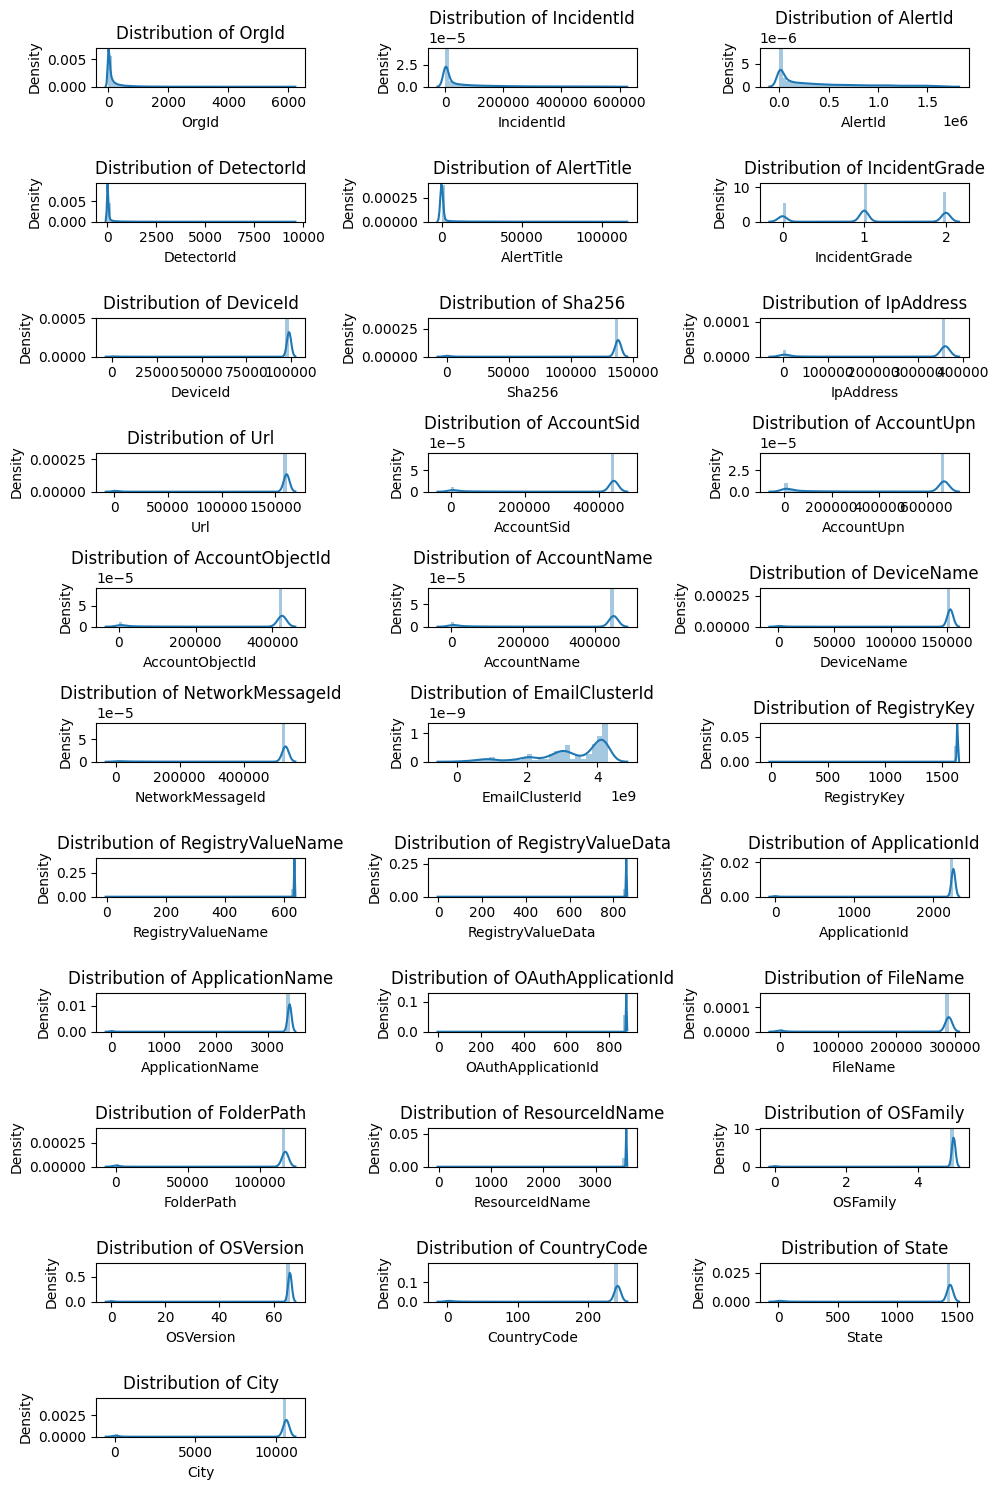

In [20]:
plot_hist(data,num_cols)

### Inferences 

UserId Distribution: The histogram shows a high frequency of certain UserIds, indicating that a few users are responsible for a large number of incidents.

IncidentId Distribution: The distribution is relatively uniform, suggesting that incidents are spread across various categories without significant clustering.

SHA256 Distribution: There are peaks at specific SHA256 values, which could indicate common malware or repeated security threats.

State Distribution: The histogram shows a concentration in certain states, possibly indicating regions with higher security incidents or better reporting mechanisms.

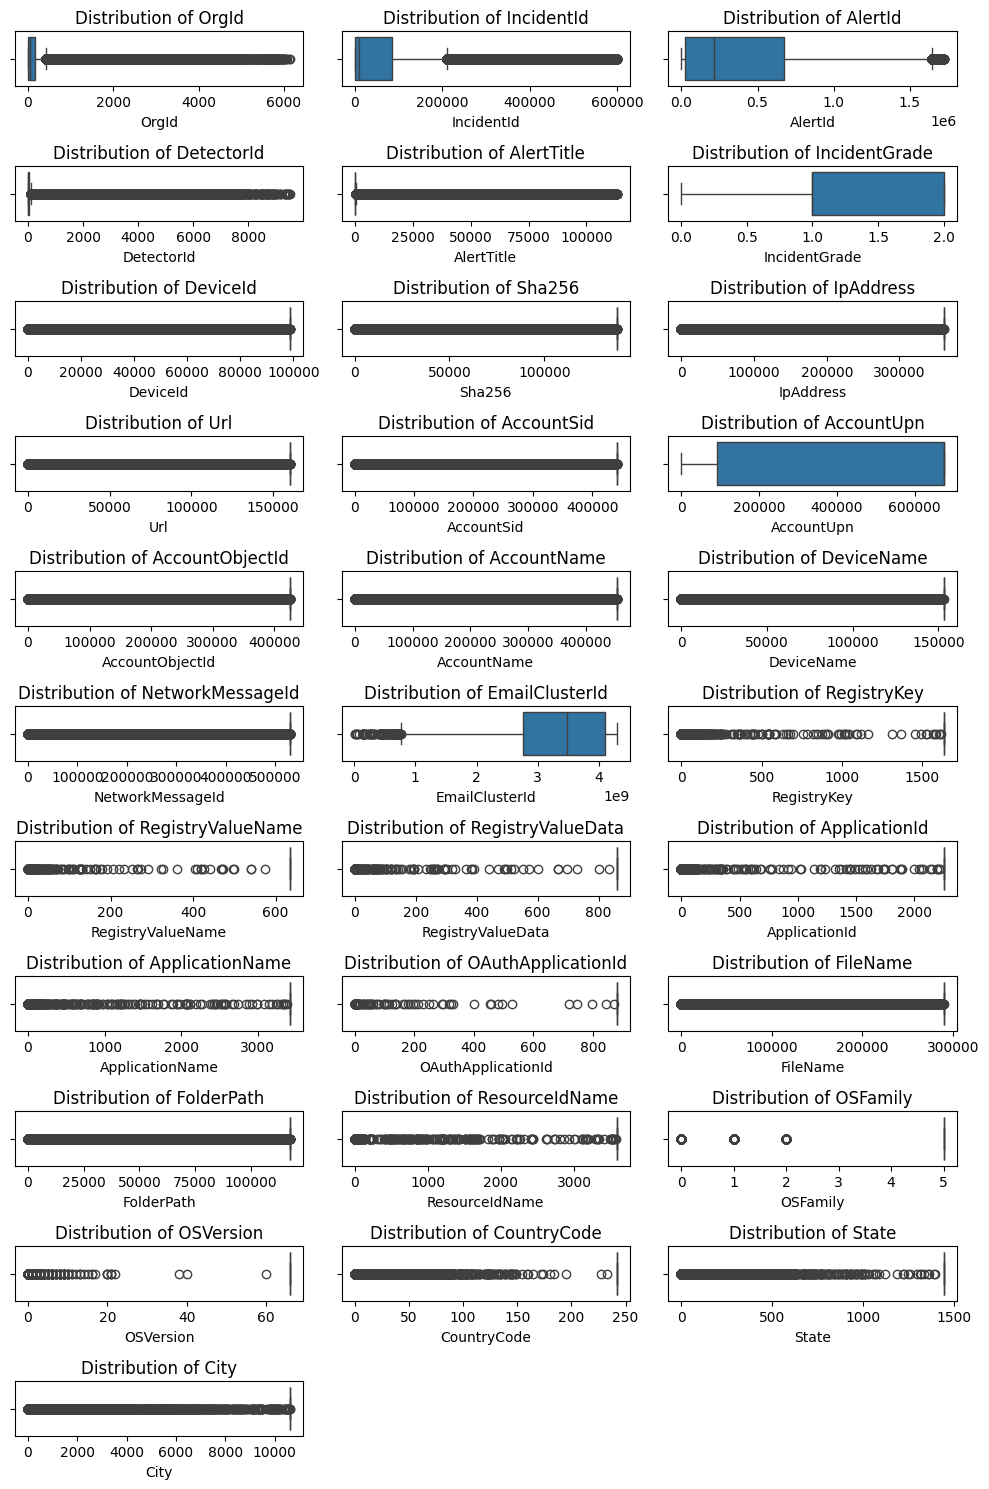

In [21]:
plot_box(data,num_cols)

In [22]:
data.nunique().sort_values(ascending=False)

AlertId               323884
Timestamp             280033
IncidentId            161213
AccountUpn            102636
AccountName            69049
AccountSid             66564
AccountObjectId        65730
NetworkMessageId       49387
IpAddress              44639
AlertTitle             33075
FileName               24104
DeviceName             18542
Url                    15687
Sha256                 14560
FolderPath             12413
DeviceId               12260
DetectorId              4563
OrgId                   3892
EmailClusterId          3190
City                    2182
MitreTechniques          827
ThreatFamily             668
State                    658
ApplicationName          306
ResourceIdName           272
RegistryKey              212
ApplicationId            187
CountryCode              152
RegistryValueData        113
RegistryValueName        108
OAuthApplicationId        73
EntityType                26
OSVersion                 25
Category                  18
ResourceType  

### Note

In this dataset, we have 46 columns, so doing EDA on all columns might not be necessary.
By understanding the columns, we will drop some columns based on their description.

#### Necessary columns
We will focus on columns that provide meaningful information about the incidents and can help in identifying patterns.

Timestamp: To analyze trends over time.
Category: To understand the types of alerts.
MitreTechniques: To identify common attack techniques.
ActionGrouped: To see how alerts are typically remediated.
EntityType: To understand what types of entities are involved.
EvidenceRole: To analyze the role of evidence in investigations.
Sha256: To identify common files involved in incidents.
IpAddress: To analyze the geographical distribution of incidents.
AccountSid: To identify common accounts involved.
DeviceName: To see which devices are frequently involved.
ThreatFamily: To identify common malware families.
OSFamily: To understand which operating systems are more prone to incidents.
SuspicionLevel: To analyze the level of suspicion.
LastVerdict: To see the final outcomes of threat analysis.
CountryCode: To analyze the geographical distribution of incidents.
State: To further drill down into geographical data.
City: To get detailed geographical insights.

#### columns to remove initially

Id: This is just a unique identifier for each threat and doesn’t provide any meaningful information for analysis. (Index)
* OrgId: While it identifies the organization, it might not be useful unless you’re specifically analyzing data across different organizations.
IncidentId: Similar to Id, it’s a unique identifier for incidents and doesn’t add value for general analysis.
AlertId: Another unique identifier that doesn’t contribute to understanding patterns or trends.
DetectorId: Identifies the detector but doesn’t provide insights into the nature of the incidents.
AlertTitle: Titles can be varied and unstructured, making them less useful for quantitative analysis.
ActionGranular: Detailed remediation actions might be too specific and not useful for high-level analysis.
DeviceId: Unique device identifiers don’t provide meaningful insights unless you’re focusing on device-specific analysis.
* url: URLs are unique and varied, making them less useful for general pattern analysis.
* AccountUpn: Email account identifiers are specific to individuals and don’t provide broader insights.
AccountObjectId: Similar to AccountUpn, it’s specific to individuals and less useful for general analysis.
AccountName: Names of accounts are unique and don’t contribute to broader pattern recognition.
NetworkMessageId: Unique identifiers for email messages are too specific for general analysis.
EmailClusterId: Unique identifiers for email clusters are also too specific.
RegistryKey: Registry keys are varied and specific, making them less useful for high-level analysis.
RegistryValueName: Similar to RegistryKey, these are too specific.
RegistryValueData: Data of registry values is detailed and specific, not useful for general trends.
* ApplicationId: Unique identifiers for applications don’t provide broader insights. Variance 0
ApplicationName: Names of applications can be varied and unstructured.
OAuthApplicationId: Unique identifiers for OAuth applications are too specific.
FileName: Names of files are varied and specific, making them less useful for general analysis.
FolderPath: Paths of file folders are detailed and specific.
* ResourceIdName: Names of Azure resources are unique and varied.
ResourceType: Types of Azure resources might be useful in some contexts but can be too specific for initial analysis.
Roles: Additional metadata on evidence roles might be too detailed for initial analysis.
OSVersion: While useful in some contexts, it might be too detailed for initial high-level analysis.
AntispamDirection: Direction of the antispam filter might not provide significant insights for general analysis.

In [23]:
from scipy.stats import *

In [24]:
data['SuspicionLevel'].value_counts()

Suspicious      75641
Incriminated       81
Name: SuspicionLevel, dtype: int64

In [25]:
contingency_table = pd.crosstab(data['SuspicionLevel'], data['IncidentGrade'])

# Perform Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print results
print(f'Chi-Square Statistic: {chi2}')
print(f'p-value: {p}')

if p < 0.05:
    print("Reject the Null Hypothesis: There is a significant association between the column and the target.")
else:
    print("Fail to Reject the Null Hypothesis: No significant association.")

Chi-Square Statistic: 2.744239013378251
p-value: 0.25356894851268336
Fail to Reject the Null Hypothesis: No significant association.


In [26]:
data['ApplicationId'].value_counts()

2251    488752
0         3254
1         2073
2         1968
3         1646
         ...  
183          1
88           1
1597         1
233          1
592          1
Name: ApplicationId, Length: 187, dtype: int64

In [27]:
# There is the effect of accountupn on incidentgrade

In [28]:
a=['OrgId', 'IncidentId','AlertId', 'Timestamp', 'DetectorId','AlertTitle', 'Category','MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath']

In [29]:
b=[]
for i in a:
    a=pd.crosstab(data[i],data['IncidentGrade'])
    tstat,pvalue,c,d=chi2_contingency(a)
    print(f' Results of chi test with {i} and Incident Grade \n pvalue: {pvalue}')
    if pvalue <0.05:
        print(i,'has a relation with Target variable(Incident Grade)\n\n')
        b.append(i)
    else:
        print(i,'has no relation with Target variable(Incident Grade)\n\n')

print(f'Significant Features are:- \n{b}')

 Results of chi test with OrgId and Incident Grade 
 pvalue: 0.0
OrgId has a relation with Target variable(Incident Grade)


 Results of chi test with IncidentId and Incident Grade 
 pvalue: 0.0
IncidentId has a relation with Target variable(Incident Grade)


 Results of chi test with AlertId and Incident Grade 
 pvalue: 0.0
AlertId has a relation with Target variable(Incident Grade)


 Results of chi test with Timestamp and Incident Grade 
 pvalue: 0.0
Timestamp has a relation with Target variable(Incident Grade)


 Results of chi test with DetectorId and Incident Grade 
 pvalue: 0.0
DetectorId has a relation with Target variable(Incident Grade)


 Results of chi test with AlertTitle and Incident Grade 
 pvalue: 0.0
AlertTitle has a relation with Target variable(Incident Grade)


 Results of chi test with Category and Incident Grade 
 pvalue: 0.0
Category has a relation with Target variable(Incident Grade)


 Results of chi test with MitreTechniques and Incident Grade 
 pvalue: 0.0
Mi

In [30]:
data['OrgId'].mean()

182.567046

In [31]:
data['OrgId']-data['OrgId'].mean()

Id
472446405890    -120.567046
1374389537640   -107.567046
111669154679    -145.567046
1460288882818    -92.567046
1185410975439   -112.567046
                    ...    
403726930016    -172.567046
953482740285    -139.567046
841813595239    -136.567046
773094117010    -179.567046
635655164240     -90.567046
Name: OrgId, Length: 500000, dtype: float64

In [32]:
import scipy.stats as stats
for col in data.select_dtypes(include=np.number):
    anova_results = stats.f_oneway(*[data[data['IncidentGrade'] == cat][col] for cat in data['IncidentGrade'].unique()])
    print(f"ANOVA results for {col}: F-statistic={anova_results[0]:.2f}, p-value={anova_results[1]:.4f}")

ANOVA results for OrgId: F-statistic=nan, p-value=nan
ANOVA results for IncidentId: F-statistic=nan, p-value=nan
ANOVA results for AlertId: F-statistic=nan, p-value=nan
ANOVA results for DetectorId: F-statistic=nan, p-value=nan
ANOVA results for AlertTitle: F-statistic=nan, p-value=nan
ANOVA results for IncidentGrade: F-statistic=nan, p-value=nan
ANOVA results for DeviceId: F-statistic=nan, p-value=nan
ANOVA results for Sha256: F-statistic=nan, p-value=nan
ANOVA results for IpAddress: F-statistic=nan, p-value=nan
ANOVA results for Url: F-statistic=nan, p-value=nan
ANOVA results for AccountSid: F-statistic=nan, p-value=nan
ANOVA results for AccountUpn: F-statistic=nan, p-value=nan
ANOVA results for AccountObjectId: F-statistic=nan, p-value=nan
ANOVA results for AccountName: F-statistic=nan, p-value=nan
ANOVA results for DeviceName: F-statistic=nan, p-value=nan
ANOVA results for NetworkMessageId: F-statistic=nan, p-value=nan
ANOVA results for EmailClusterId: F-statistic=nan, p-value=nan


In [33]:
data.columns

Index(['OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')

In [34]:
# a=['OrgId', 'IncidentId','AlertId', 'Timestamp', 'DetectorId','AlertTitle', 'Category','MitreTechniques', 'IncidentGrade',
#     'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
#      'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
#      'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
#      'EmailClusterId', 'RegistryKey', 'RegistryValueName',
#      'RegistryValueData', 'ApplicationId', 'ApplicationName',
#      'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath']

In [35]:
a=pd.crosstab(data['AccountUpn'],data['IncidentGrade'])
chi2_contingency(a)

Chi2ContingencyResult(statistic=344317.7217260174, pvalue=0.0, dof=202484, expected_freq=array([[1.62413514e+02, 3.28347973e+02, 2.65238514e+02],
       [1.08275676e+02, 2.18898649e+02, 1.76825676e+02],
       [9.98972008e+01, 2.01960063e+02, 1.63142736e+02],
       ...,
       [2.14832690e-01, 4.34322716e-01, 3.50844595e-01],
       [2.14832690e-01, 4.34322716e-01, 3.50844595e-01],
       [6.82297881e+04, 1.37938723e+05, 1.11426489e+05]]))

In [36]:
data['AlertTitle'].value_counts()

0        69490
1        40802
2        31549
3        21847
4        21698
         ...  
94311        1
65152        1
37075        1
16430        1
33745        1
Name: AlertTitle, Length: 33075, dtype: int64

In [37]:
data['DetectorId'].value_counts()

0       69490
1       40802
2       31549
3       25776
4       21847
        ...  
4020        1
4389        1
4889        1
7550        1
4198        1
Name: DetectorId, Length: 4563, dtype: int64

In [38]:
data['AlertId'].value_counts()

0         570
3         154
2         134
6          81
118        77
         ... 
362651      1
715070      1
591821      1
112056      1
253715      1
Name: AlertId, Length: 323884, dtype: int64

In [39]:
data[data['OrgId']==0]

,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,ActionGrouped,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
Id,,,,,,,,,,,,,,,,,,,,,
103079216833,0,58,381066,2024-06-09 07:46:55+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1520418424539,0,311,43218,2024-06-05 03:19:26+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
214748366556,0,114,863798,2024-06-07 21:24:22+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1082331760380,0,333,503639,2024-06-04 14:32:58+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1245540517659,0,83,819180,2024-06-06 00:38:41+00:00,4,3,InitialAccess,NaN,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,3,514,1648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1468878816981,0,134,1172894,2024-06-09 01:01:41+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1245540517659,0,83,1191630,2024-06-07 06:13:51+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
1443109013265,0,303,69083,2024-06-04 23:26:51+00:00,0,0,InitialAccess,T1078;T1078.004,2.0,NaN,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


In [40]:
data.groupby(by=['OrgId','IncidentId','AlertId','DetectorId'])['IncidentId'].count().head(50)

OrgId  IncidentId  AlertId  DetectorId
0      21          7329     195           7
                   35235    252           2
                   160231   4             1
                   161219   4             1
                   161343   0             1
                   162285   0             1
                   162496   0             1
                   164991   0             1
                   165116   0             1
                   165229   7             1
                   166840   0             1
                   169255   4             1
                   170021   0             2
                   170686   4             1
                   170817   0             1
                   172256   0             1
                   172661   4             1
                   173210   0             1
                   175978   0             1
                   176447   4             1
                   176677   0             1
                   178966   4        

In [41]:
data['OrgId'].value_counts()

0       44211
2       12755
1       11134
3        9953
5        9273
        ...  
3167        1
5987        1
3122        1
3480        1
2161        1
Name: OrgId, Length: 3892, dtype: int64

In [42]:
data.columns

Index(['OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')

In [43]:
df=['Category','MitreTechniques','EntityType','EvidenceRole','Sha256','IpAddress',
'AccountSid','OSFamily','LastVerdict','CountryCode','State','City',
'OrgId','url','AccountUpn','NetworkMessageId',
'FolderPath','Roles','AccountObjectId','FileName']

## Data clean

In [44]:
data.columns

Index(['OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')

In [45]:
df=data.drop(columns=['OrgId','IncidentId','AlertId','DetectorId',
                      'AlertTitle','ActionGranular','DeviceId','AccountName','DeviceName',
                      'EmailClusterId','RegistryKey','RegistryValueName','RegistryValueData','ApplicationId',
                      'ApplicationName','OAuthApplicationId','ThreatFamily','ResourceIdName','ResourceType',
                      'OSVersion','AntispamDirection','Roles'])

In [46]:
df.isnull().mean()*100

Timestamp            0.0000
Category             0.0000
MitreTechniques     57.5170
IncidentGrade        0.5440
ActionGrouped       99.4054
EntityType           0.0000
EvidenceRole         0.0000
Sha256               0.0000
IpAddress            0.0000
Url                  0.0000
AccountSid           0.0000
AccountUpn           0.0000
AccountObjectId      0.0000
NetworkMessageId     0.0000
FileName             0.0000
FolderPath           0.0000
OSFamily             0.0000
SuspicionLevel      84.8556
LastVerdict         76.5328
CountryCode          0.0000
State                0.0000
City                 0.0000
dtype: float64

In [47]:
df.columns

Index(['Timestamp', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'EntityType', 'EvidenceRole', 'Sha256', 'IpAddress',
       'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId',
       'NetworkMessageId', 'FileName', 'FolderPath', 'OSFamily',
       'SuspicionLevel', 'LastVerdict', 'CountryCode', 'State', 'City'],
      dtype='object')

In [48]:
col=['MitreTechniques','IncidentGrade','SuspicionLevel','LastVerdict']
for i in col:
    print(f"Value counts for {i}:")
    print(df[i].value_counts())
    print("\n" + "-"*50 + "\n")

Value counts for MitreTechniques:
T1078;T1078.004                    70740
T1566.002                          42820
T1566                              34950
T1133                               7665
T1566.001                           7123
                                   ...  
T1020;T1567.002                        1
T1112;T1562.001                        1
T1046;T1135;T1018                      1
T1005;T1087.003;T1114;T1114.001        1
T1003.008                              1
Name: MitreTechniques, Length: 827, dtype: int64

--------------------------------------------------

Value counts for IncidentGrade:
1.0    215980
2.0    174468
0.0    106832
Name: IncidentGrade, dtype: int64

--------------------------------------------------

Value counts for SuspicionLevel:
Suspicious      75641
Incriminated       81
Name: SuspicionLevel, dtype: int64

--------------------------------------------------

Value counts for LastVerdict:
Suspicious                                            736

In [49]:
for i in col:
    print(df[i].describe())

count              212415
unique                827
top       T1078;T1078.004
freq                70740
Name: MitreTechniques, dtype: object
count    497280.000000
mean          1.136012
std           0.739716
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: IncidentGrade, dtype: float64
count          75722
unique             2
top       Suspicious
freq           75641
Name: SuspicionLevel, dtype: object
count         117336
unique             5
top       Suspicious
freq           73695
Name: LastVerdict, dtype: object


In [50]:
df.head()

,Timestamp,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,EvidenceRole,Sha256,IpAddress,Url,...,AccountObjectId,NetworkMessageId,FileName,FolderPath,OSFamily,SuspicionLevel,LastVerdict,CountryCode,State,City
Id,,,,,,,,,,,,,,,,,,,,,
472446405890,2024-06-15 01:47:48+00:00,SuspiciousActivity,NaN,2.0,NaN,CloudApplication,Impacted,138268,360606,160396,...,425863,529644,289573,117668,5,NaN,NaN,242,1445,10630
1374389537640,2024-06-11 17:38:44+00:00,InitialAccess,T1078;T1078.004,2.0,NaN,Ip,Related,138268,50,160396,...,425863,529644,289573,117668,5,NaN,NaN,1,0,0
111669154679,2024-06-06 15:44:59+00:00,Exfiltration,NaN,0.0,NaN,MailMessage,Impacted,138268,360606,160396,...,425863,15216,289573,117668,5,NaN,NaN,242,1445,10630
1460288882818,2024-06-04 18:53:10+00:00,InitialAccess,T1078;T1078.004,2.0,NaN,User,Impacted,138268,360606,160396,...,4833,529644,289573,117668,5,NaN,NaN,242,1445,10630
1185410975439,2024-06-06 09:22:42+00:00,InitialAccess,T1566.002,1.0,NaN,Url,Related,138268,360606,6528,...,425863,529644,289573,117668,5,NaN,Malicious,242,1445,10630


### Visualization



In [51]:
df.drop_duplicates(inplace=True)

In [52]:
# Extracting the feature from the Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S%z')

df['hour'] = df['Timestamp'].dt.hour
df['day'] = df['Timestamp'].dt.day
df['month'] = df['Timestamp'].dt.month
df['weekofday']=df['Timestamp'].dt.dayofweek

In [53]:
df.drop(columns='Timestamp',inplace=True)

In [54]:
df.head(10)

,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,EvidenceRole,Sha256,IpAddress,Url,AccountSid,...,OSFamily,SuspicionLevel,LastVerdict,CountryCode,State,City,hour,day,month,weekofday
Id,,,,,,,,,,,,,,,,,,,,,
472446405890,SuspiciousActivity,NaN,2.0,NaN,CloudApplication,Impacted,138268,360606,160396,441377,...,5,NaN,NaN,242,1445,10630,1,15,6,5
1374389537640,InitialAccess,T1078;T1078.004,2.0,NaN,Ip,Related,138268,50,160396,441377,...,5,NaN,NaN,1,0,0,17,11,6,1
111669154679,Exfiltration,NaN,0.0,NaN,MailMessage,Impacted,138268,360606,160396,441377,...,5,NaN,NaN,242,1445,10630,15,6,6,3
1460288882818,InitialAccess,T1078;T1078.004,2.0,NaN,User,Impacted,138268,360606,160396,4861,...,5,NaN,NaN,242,1445,10630,18,4,6,1
1185410975439,InitialAccess,T1566.002,1.0,NaN,Url,Related,138268,360606,6528,441377,...,5,NaN,Malicious,242,1445,10630,9,6,6,3
206158435077,DefenseEvasion,T1105;T1140;T1216;T1218;T1218.003;T1218.004;T1...,1.0,NaN,File,Related,824,360606,160396,441377,...,5,Suspicious,Suspicious,242,1445,10630,0,10,6,0
1159641173697,CommandAndControl,NaN,1.0,NaN,Url,Related,138268,360606,112536,441377,...,5,Suspicious,Suspicious,242,1445,10630,7,7,6,4
25769805966,Exfiltration,NaN,1.0,NaN,Machine,Impacted,138268,360606,160396,441377,...,5,NaN,NaN,242,1445,10630,12,14,6,4
1683627184248,InitialAccess,T1078;T1078.004,2.0,NaN,User,Impacted,138268,360606,160396,8522,...,5,NaN,NaN,242,1445,10630,15,4,6,1


In [55]:
df.columns

Index(['Category', 'MitreTechniques', 'IncidentGrade', 'ActionGrouped',
       'EntityType', 'EvidenceRole', 'Sha256', 'IpAddress', 'Url',
       'AccountSid', 'AccountUpn', 'AccountObjectId', 'NetworkMessageId',
       'FileName', 'FolderPath', 'OSFamily', 'SuspicionLevel', 'LastVerdict',
       'CountryCode', 'State', 'City', 'hour', 'day', 'month', 'weekofday'],
      dtype='object')

In [56]:
df.dtypes

Category             object
MitreTechniques      object
IncidentGrade       float64
ActionGrouped        object
EntityType           object
EvidenceRole         object
Sha256                int64
IpAddress             int64
Url                   int64
AccountSid            int64
AccountUpn            int64
AccountObjectId       int64
NetworkMessageId      int64
FileName              int64
FolderPath            int64
OSFamily              int64
SuspicionLevel       object
LastVerdict          object
CountryCode           int64
State                 int64
City                  int64
hour                  int64
day                   int64
month                 int64
weekofday             int64
dtype: object

In [57]:
numerical_cols = [ 'hour', 'day', 'month']


categorical_cols = ['Category', 'MitreTechniques', 'ActionGrouped', 'EntityType', 
                    'EvidenceRole', 'ThreatFamily', 'OSFamily', 'SuspicionLevel', 
                    'LastVerdict', 'CountryCode', 'State', 'City']


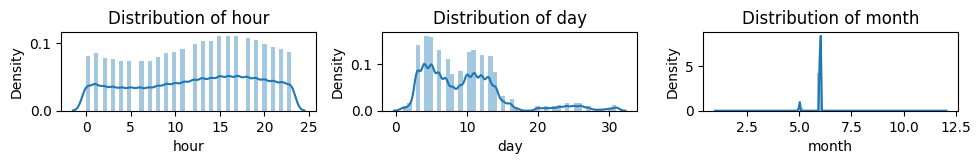

In [58]:
plot_hist(df,numerical_cols)

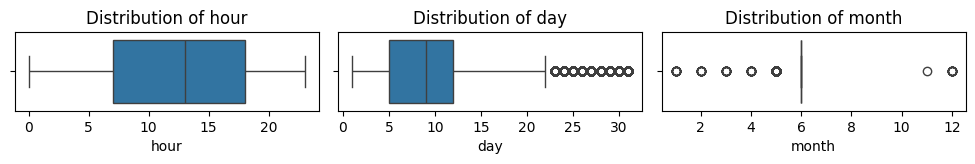

In [59]:
plot_box(df,numerical_cols)

### Inferences

Distribution of Hour: The activity is spread throughout the day, with some hours showing higher density. This could indicate peak times for certain events or activities.

Distribution of Day: The density varies across days, suggesting that certain days of the month have more frequent occurrences of the events being tracked.

Distribution of Month: The activity is distributed across different months, with some months showing higher density. This could indicate seasonal trends or specific periods with increased activity.

In [60]:
df = df.reset_index(drop=True)

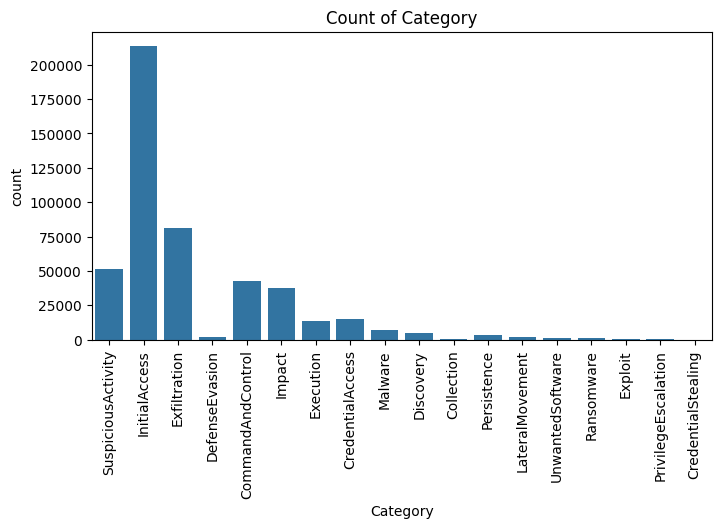

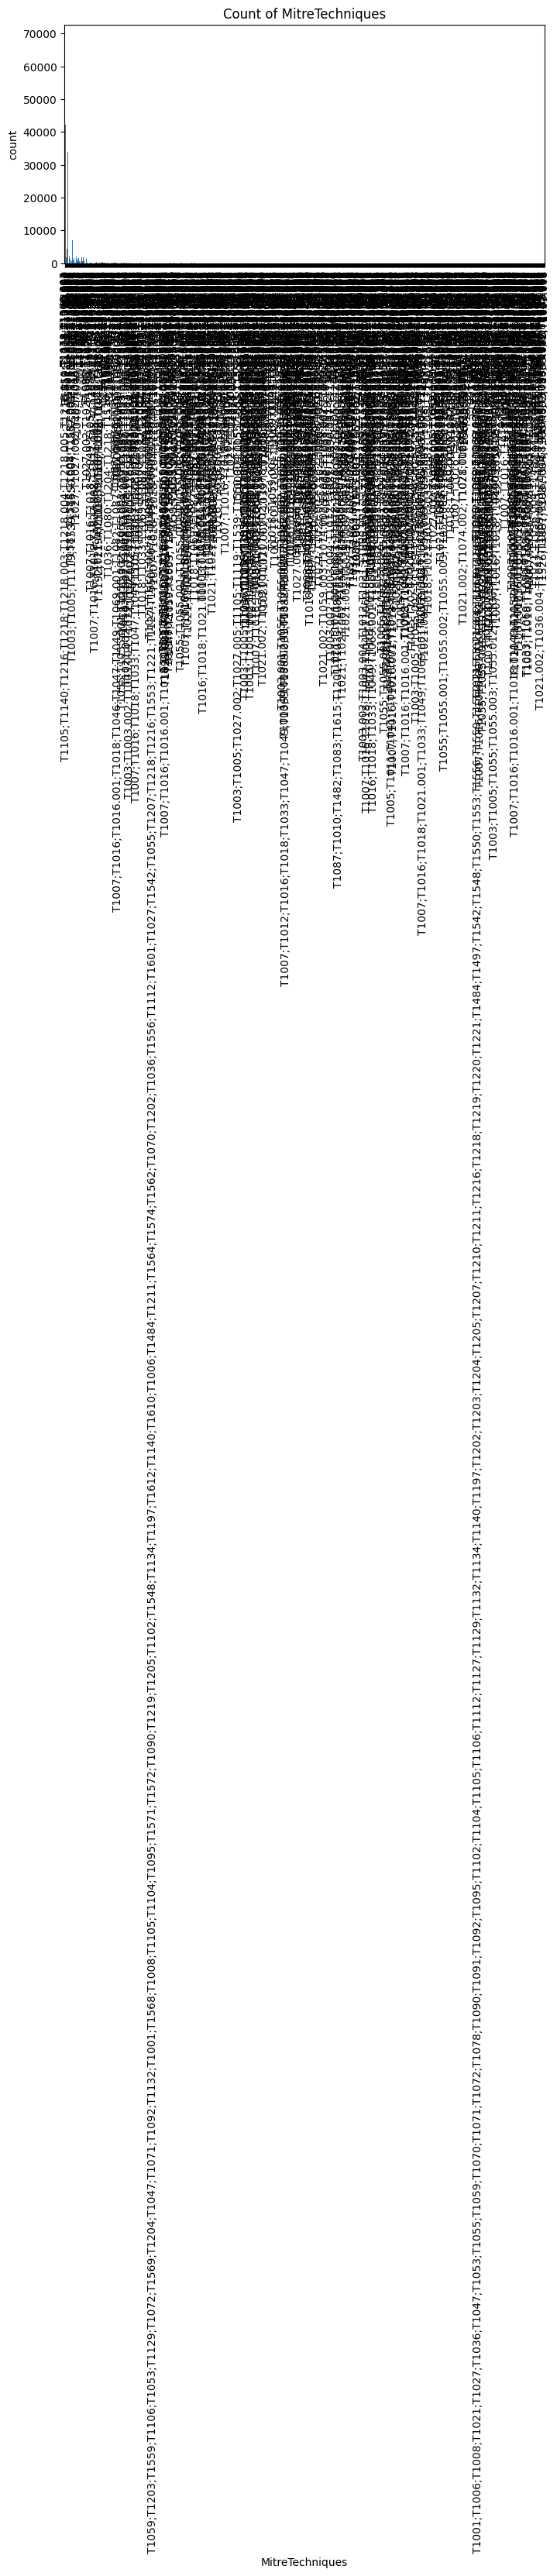

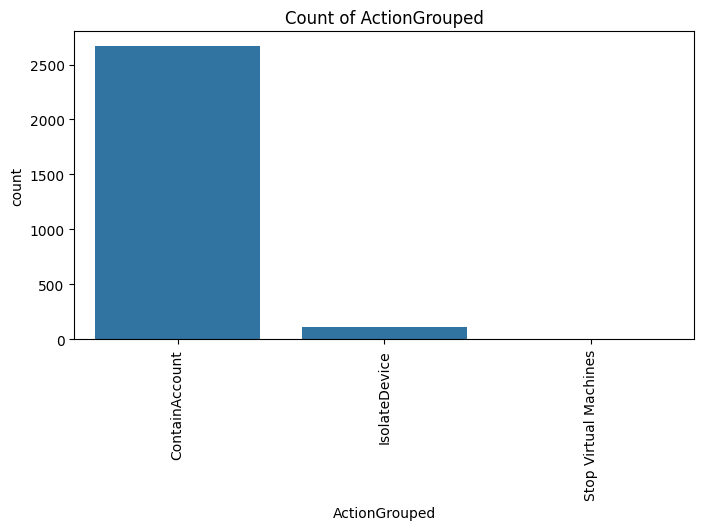

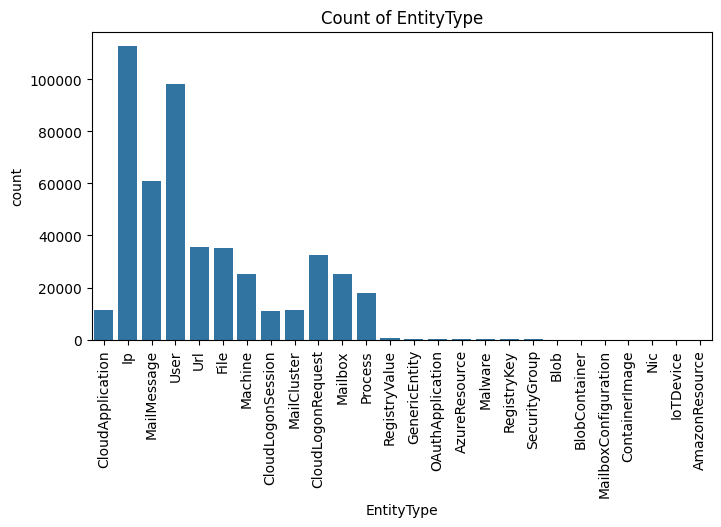

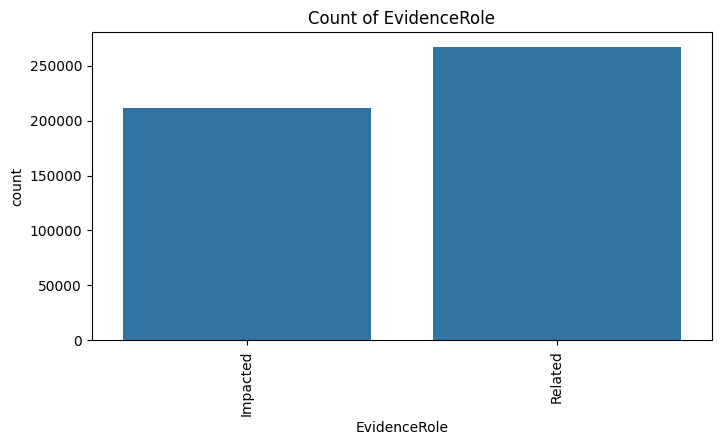

KeyError: 'ThreatFamily'

<Figure size 800x400 with 0 Axes>

In [61]:
for i in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=df[i])
    plt.title(f'Count of {i}')
    plt.xticks(rotation=90)
    plt.show()

### Inferences

category
* “Count of Category,” the highest count is for “Suspicious Activity,” indicating it is the most frequent category. Other notable categories include “Malware” and “Defense Evasion,” which also have significant counts. This suggests a focus on monitoring and addressing these specific types of threats.

ActionGrouped
* “Count of ActionGrouped,” the action ‘CombineAccount’ has the highest count, indicating it is the most frequently performed action. The other actions, ‘IsolateDevice’ and ‘Stop Virtual Machines,’ have zero counts, suggesting they are rarely or never performed. This highlights a significant focus on account-related actions.

Entity Type
* “Count of EntityType,” ‘CloudApplication’ has the highest count, indicating it is the most frequently occurring entity type. Other entities like ‘Malware’ and ‘Machine’ have significantly lower counts, suggesting they are less common in comparison. This highlights a strong focus on cloud applications in the dataset.

Evidence Role
*  “Count of EvidenceRole,” both ‘Impacted’ and ‘Related’ categories have identical counts, each reaching 160,000. This suggests a balanced distribution between these two roles in the dataset, indicating that both are equally significant in the context of evidence roles.

OS Family
*  “Count of OSFamily,” the OSFamily labeled ‘5’ has the highest count, indicating it is the most prevalent operating system family in the dataset. The other OSFamily values have significantly lower counts, suggesting a strong dominance of OSFamily ‘5’.

Suspicion Level
* “Count of SuspicionLevel,” the ‘Suspicious’ category has a significantly higher count compared to the ‘Incriminated’ category. This indicates that there are many more instances flagged as suspicious than those confirmed as incriminated in the dataset.

Last Verdict
* “Count of LastVerdict,” the ‘Non-malicious’ category has the highest count, indicating it is the most common verdict. The ‘Malicious’ and ‘Suspicious’ categories have significantly lower counts, suggesting fewer confirmed threats. This highlights a predominance of non-threatening incidents in the dataset.


### Bivariate Analysis and Multivariate Analysis

In [62]:
df.columns

Index(['Category', 'MitreTechniques', 'IncidentGrade', 'ActionGrouped',
       'EntityType', 'EvidenceRole', 'Sha256', 'IpAddress', 'Url',
       'AccountSid', 'AccountUpn', 'AccountObjectId', 'NetworkMessageId',
       'FileName', 'FolderPath', 'OSFamily', 'SuspicionLevel', 'LastVerdict',
       'CountryCode', 'State', 'City', 'hour', 'day', 'month', 'weekofday'],
      dtype='object')

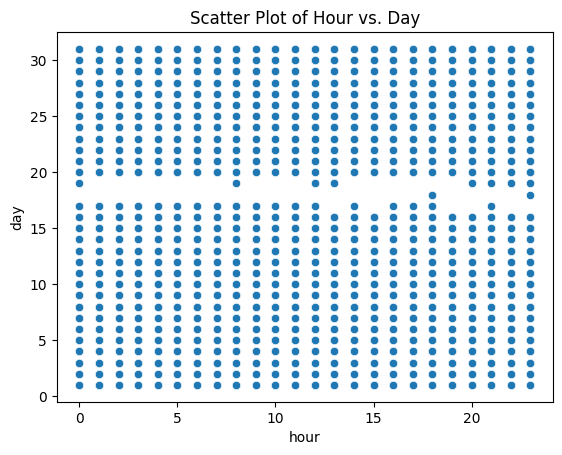

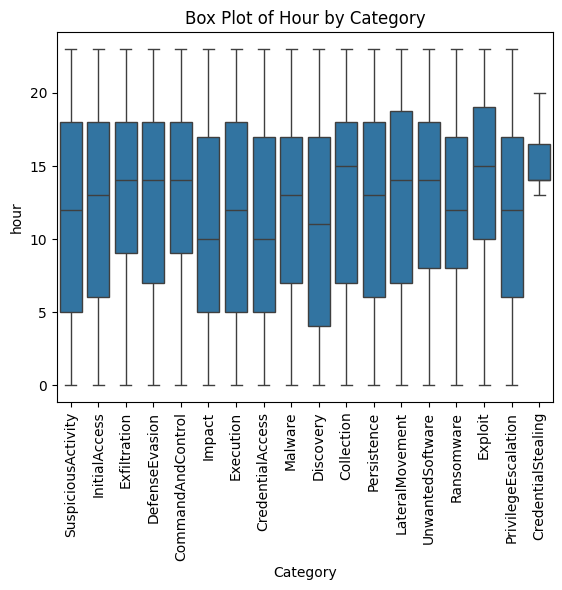

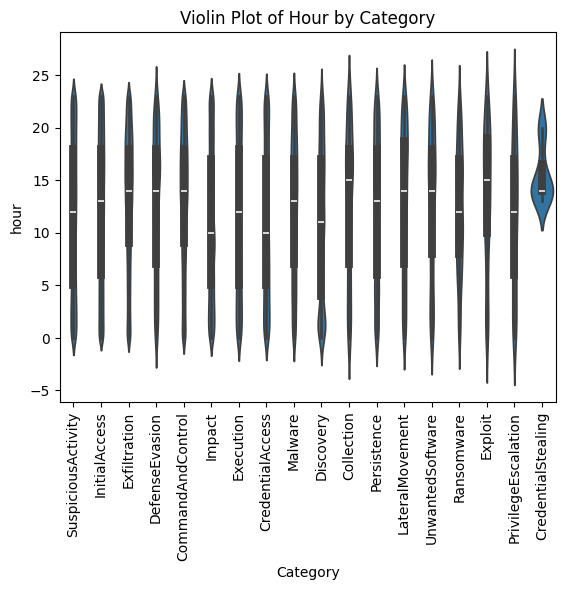

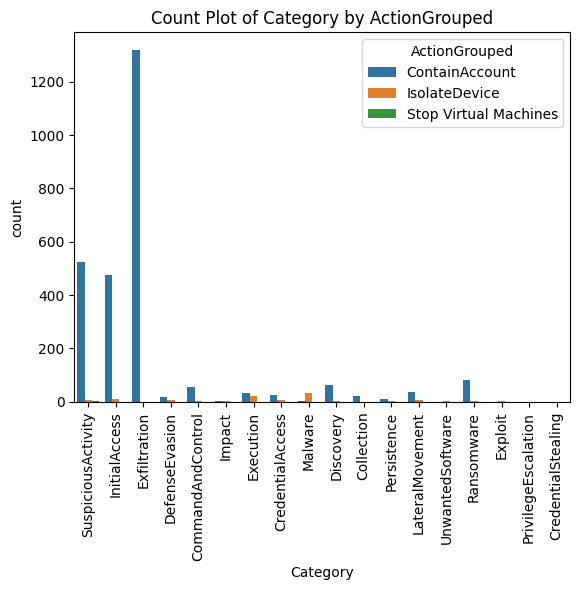

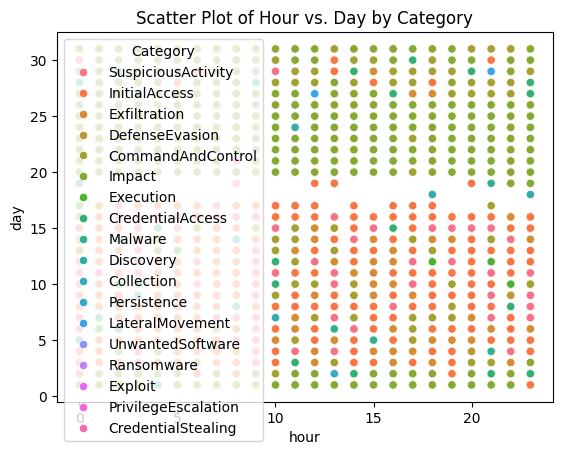

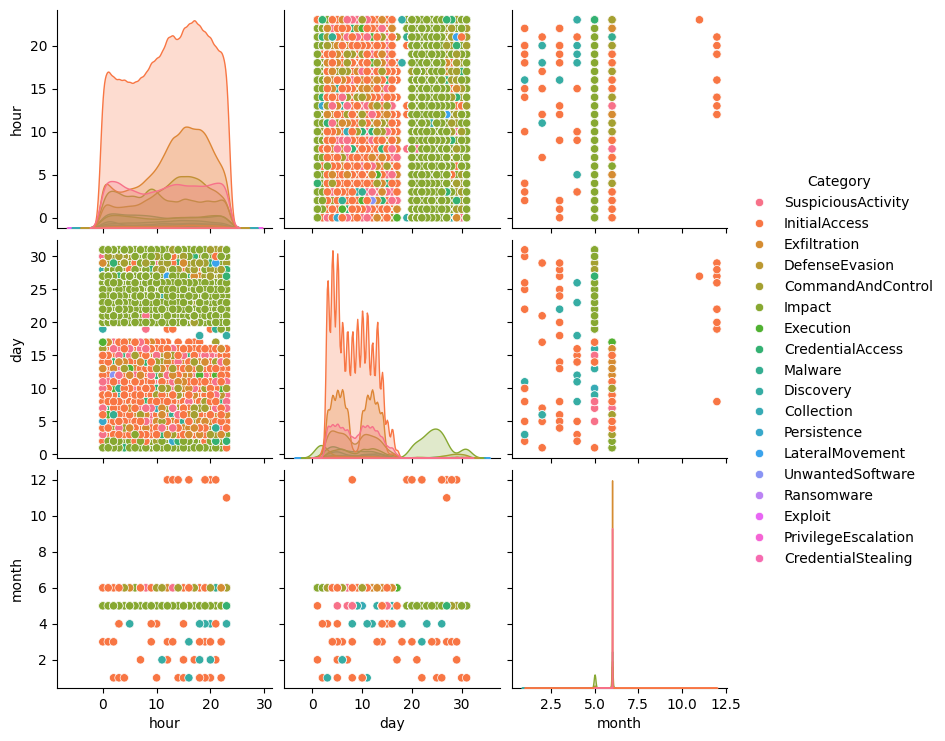

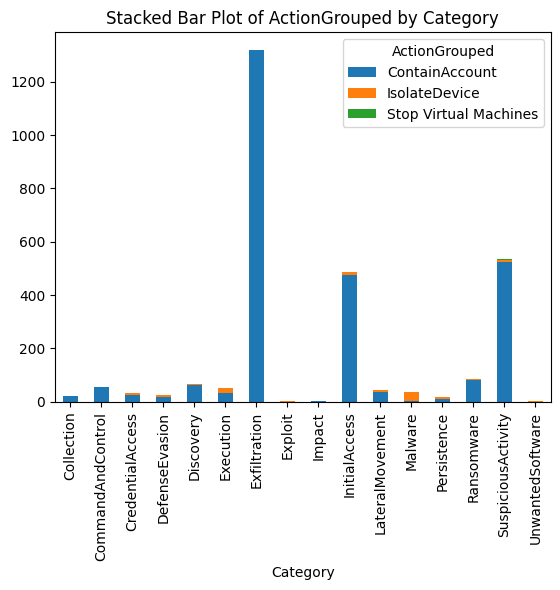

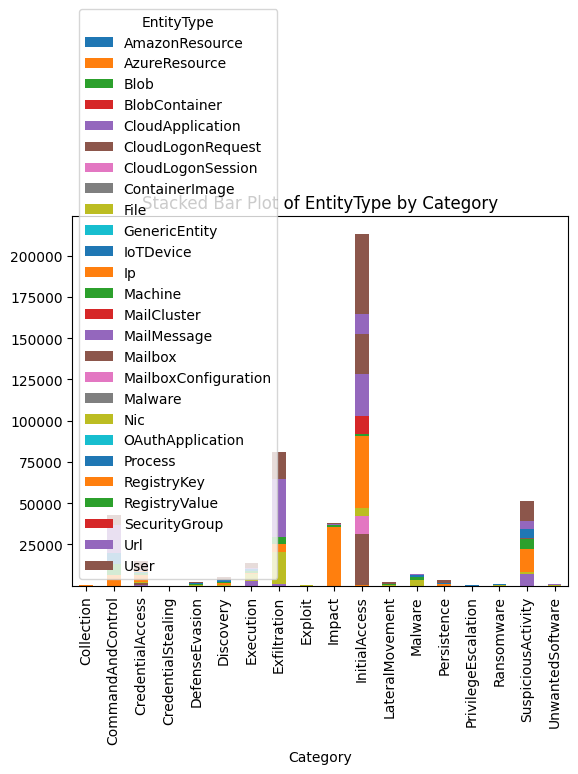

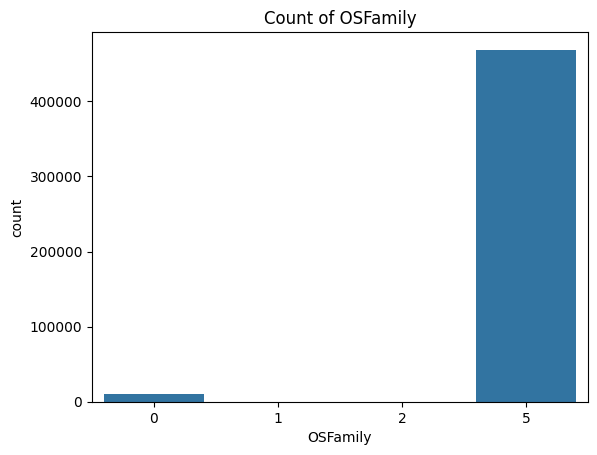

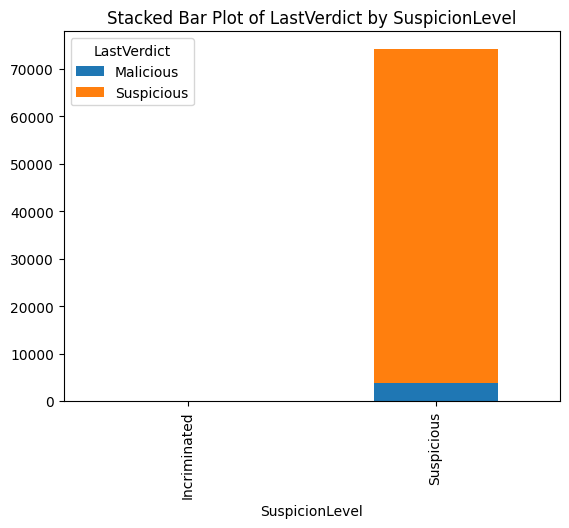

In [63]:
sns.scatterplot(x=df['hour'], y=df['day'])
plt.title('Scatter Plot of Hour vs. Day')
plt.show()

sns.boxplot(data=df, x='Category', y='hour')
plt.title('Box Plot of Hour by Category')
plt.xticks(rotation=90)
plt.show()

sns.violinplot(data=df, x='Category', y='hour')
plt.title('Violin Plot of Hour by Category')
plt.xticks(rotation=90)
plt.show()

sns.countplot(data=df, x='Category', hue='ActionGrouped')
plt.title('Count Plot of Category by ActionGrouped')
plt.xticks(rotation=90)
plt.show()

sns.scatterplot(data=df, x='hour', y='day', hue='Category')
plt.title('Scatter Plot of Hour vs. Day by Category')
plt.show()

sns.pairplot(df[['hour', 'day', 'month', 'Category']], hue='Category')
plt.show()

pd.crosstab(df['Category'], df['ActionGrouped']).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Plot of ActionGrouped by Category')
plt.show()

pd.crosstab(df['Category'], df['EntityType']).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Plot of EntityType by Category')
plt.show()

sns.countplot(data=df, x='OSFamily')
plt.title('Count of OSFamily')
plt.show()

pd.crosstab(df['SuspicionLevel'], df['LastVerdict']).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Plot of LastVerdict by SuspicionLevel')
plt.show()

### Inferences

Scatter Plot of Hour vs. Day
* The data points are evenly distributed across all hours and days, suggesting consistent activity throughout the entire period. This indicates that events or observations are recorded uniformly across different times and days.

Box Plot of Hour by Category
* Suspicious Activity: Incidents are spread throughout the day, with a higher concentration in the early hours.
* Malware: Most incidents occur around midday.
* Unauthorized Access: Incidents are more frequent in the late evening hours.

Violen Plot of hour by category
* Suspicious Activity: This category shows a wide distribution, indicating that suspicious activities occur throughout the day, with no specific peak hours.
* Exfiltration: This activity tends to peak during certain hours, suggesting targeted attempts to extract data at specific times.
* Credential Access: The distribution is more concentrated, indicating that credential access attempts are more likely to occur during specific hours.
* Ransomware: This category shows a distinct peak, suggesting that ransomware activities are more likely to occur at certain times, which could be crucial for monitoring and prevention efforts.

Count Plot of Category by ActionGrouped

* Suspicious Activity: This category has the highest count, indicating it is the most frequently observed threat. This suggests a need for robust monitoring and response strategies for suspicious activities.
* Malware and Credential Access: These categories also have high counts, highlighting the importance of focusing on malware detection and credential security measures.
* ContainDevice and StopVirtualMachines: These actions are commonly taken across various threat categories, emphasizing their importance in mitigating cyber threats.
* Ransomware and Phishing: Although less frequent, these categories still pose significant risks and should not be overlooked in cybersecurity strategies. 

Scatter Plot of hours vs day
* Initial Access and Execution: These categories show a concentration of occurrences during specific hours and days, indicating targeted activities at particular times.
* Credential Access and Privilege Escalation: These activities are spread across various hours and days, suggesting ongoing attempts to gain unauthorized access.
* Ransomware and Malware: These categories have distinct clusters, highlighting periods of increased activity, which could be critical for threat detection and response.
* Lateral Movement and Command and Control: These categories show patterns that could indicate coordinated efforts to move laterally within networks and establish control.

Stacked Bar plot of Actiongrouped by category
* Execution: The ‘Stop Virtual Machines’ action is significantly higher in this category, indicating a strong response to execution threats.
* Suspicious Activity: This category has a high count across all actions, highlighting its frequent occurrence and the need for comprehensive monitoring.
* Credential Access: Actions like ‘ContainAccount’ and ‘IsolateDevice’ are commonly taken, emphasizing the importance of securing credentials.

Stacked Bar Plot of entity type by category
* Cloud Resources: These are frequently involved across multiple categories, indicating their significant role in various cybersecurity incidents.
* Files and Generic Entities: These entities show high counts in categories like ‘Collection Access’ and ‘Configuration Change,’ suggesting common targets for these actions.
* IoT Devices and Mail Clusters: These have lower counts but are still notable, highlighting their presence in specific categories and the need for targeted security measures.

Stacked Bar Plot of LastVerdict by suspicious level
* Incriminated Category: This category has a small portion of ‘Malicious’ verdicts and a large portion of ‘Suspicious’ verdicts, indicating that most incriminated cases are deemed suspicious rather than malicious.
* Suspicious Category: This category consists entirely of ‘Suspicious’ verdicts, showing a clear distinction from the ‘Incriminated’ category.
* Overall Trend: The data suggests that suspicious activities are more prevalent and less likely to be classified as malicious.

### Summary of Findings and Recommendations
Activity Trends:

* Hourly and Daily Patterns: Peak activity times suggest when to allocate more resources. Action: Adjust staffing and system performance during these periods.
* Monthly Trends: Certain months show increased activity. Action: Plan for higher loads during these times and adjust strategies accordingly.

Categorical Insights:

* Categories: “Suspicious Activity” is the most common, with notable mentions of “Malware” and “Defense Evasion.” Action: Focus on enhancing monitoring and response strategies for these categories.
* Action Types: ‘CombineAccount’ is the most frequently performed action, while others are rarely used. Action: Review and potentially increase the use of less common actions.
* Entity Types: ‘CloudApplication’ dominates the dataset. Action: Strengthen security measures specifically for cloud applications.
* Evidence Roles: ‘Impacted’ and ‘Related’ roles are equally significant. Action: Maintain balanced attention and resources for both roles.
* OS Family: OSFamily ‘5’ is most prevalent. Action: Focus security efforts on this operating system.
* Suspicion vs. Confirmation: Higher counts of ‘Suspicious’ incidents suggest a need for improved verification. Action: Enhance investigation processes to better confirm and address threats.
* Verdict Distribution: Most incidents are classified as ‘Non-malicious’. Action: Refine detection systems to better identify and handle malicious threats.
 

In [64]:
print("Columns in df:")
print(df.columns)

print("\nCategorical Columns:")
print(categorical_cols)

Columns in df:
Index(['Category', 'MitreTechniques', 'IncidentGrade', 'ActionGrouped',
       'EntityType', 'EvidenceRole', 'Sha256', 'IpAddress', 'Url',
       'AccountSid', 'AccountUpn', 'AccountObjectId', 'NetworkMessageId',
       'FileName', 'FolderPath', 'OSFamily', 'SuspicionLevel', 'LastVerdict',
       'CountryCode', 'State', 'City', 'hour', 'day', 'month', 'weekofday'],
      dtype='object')

Categorical Columns:
['Category', 'MitreTechniques', 'ActionGrouped', 'EntityType', 'EvidenceRole', 'ThreatFamily', 'OSFamily', 'SuspicionLevel', 'LastVerdict', 'CountryCode', 'State', 'City']


In [65]:
categorical_cols = [col for col in categorical_cols if col in df.columns]

### Statistical Tests 

In [66]:
for col in categorical_cols:
    for col2 in categorical_cols:
        if col != col2:
            contingency_table = pd.crosstab(df[col], df[col2])
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            print(f'\nChi-Square Test between {col} and {col2}')
            print(f'Null Hypothesis: There is no association between {col} and {col2}.')
            print(f'Chi2 Statistic: {chi2}')
            print(f'p-value: {p}')
            if p < 0.05:
                print('Reject the Null Hypothesis: There is an association between the variables.')
            else:
                print('Fail to Reject the Null Hypothesis: There is no significant association between the variables.')


Chi-Square Test between Category and MitreTechniques
Null Hypothesis: There is no association between Category and MitreTechniques.
Chi2 Statistic: 2680719.3077949993
p-value: 0.0
Reject the Null Hypothesis: There is an association between the variables.

Chi-Square Test between Category and ActionGrouped
Null Hypothesis: There is no association between Category and ActionGrouped.
Chi2 Statistic: 1184.1821193605044
p-value: 5.514737113412186e-230
Reject the Null Hypothesis: There is an association between the variables.

Chi-Square Test between Category and EntityType
Null Hypothesis: There is no association between Category and EntityType.
Chi2 Statistic: 597543.3207305488
p-value: 0.0
Reject the Null Hypothesis: There is an association between the variables.

Chi-Square Test between Category and EvidenceRole
Null Hypothesis: There is no association between Category and EvidenceRole.
Chi2 Statistic: 114818.0868276686
p-value: 0.0
Reject the Null Hypothesis: There is an association be

In [67]:
from scipy.stats import ttest_ind

# Example: comparing 'hour' between two categories in 'Category'
category1 = df[df['Category'] == 'Category1']['hour']
category2 = df[df['Category'] == 'Category2']['hour']

t_stat, p_value = ttest_ind(category1, category2)
print(f'\nT-Test between Category1 and Category2 for hour')
print(f'Null Hypothesis: There is no significant difference between the means of hour for Category1 and Category2.')
print(f'T-statistic: {t_stat}')
print(f'p-value: {p_value}')
if p_value < 0.05:
    print('Reject the Null Hypothesis: There is a significant difference between the means.')
else:
    print('Fail to Reject the Null Hypothesis: There is no significant difference between the means.')



T-Test between Category1 and Category2 for hour
Null Hypothesis: There is no significant difference between the means of hour for Category1 and Category2.
T-statistic: nan
p-value: nan
Fail to Reject the Null Hypothesis: There is no significant difference between the means.


In [68]:
from scipy.stats import f_oneway

# Example: comparing 'hour' across different 'Category'
groups = [df[df['Category'] == cat]['hour'] for cat in df['Category'].unique()]

f_stat, p_value = f_oneway(*groups)
print(f'\nANOVA for hour across different Categories')
print(f'Null Hypothesis: There is no significant difference between the means of hour across different Categories.')
print(f'F-statistic: {f_stat}')
print(f'p-value: {p_value}')
if p_value < 0.05:
    print('Reject the Null Hypothesis: There is a significant difference between the means.')
else:
    print('Fail to Reject the Null Hypothesis: There is no significant difference between the means.')



ANOVA for hour across different Categories
Null Hypothesis: There is no significant difference between the means of hour across different Categories.
F-statistic: 302.2975985024324
p-value: 0.0
Reject the Null Hypothesis: There is a significant difference between the means.


In [69]:
from scipy.stats import pearsonr, spearmanr

# Example: correlation between 'hour' and 'day'
x = df['hour']
y = df['day']

# Pearson Correlation
pearson_corr, p_value_pearson = pearsonr(x, y)
print(f'\nPearson Correlation between hour and day')
print(f'Null Hypothesis: There is no correlation between hour and day.')
print(f'Pearson Correlation: {pearson_corr}')
print(f'p-value: {p_value_pearson}')
if p_value_pearson < 0.05:
    print('Reject the Null Hypothesis: There is a significant correlation between the variables.')
else:
    print('Fail to Reject the Null Hypothesis: There is no significant correlation between the variables.')

# Spearman Correlation
spearman_corr, p_value_spearman = spearmanr(x, y)
print(f'\nSpearman Correlation between hour and day')
print(f'Null Hypothesis: There is no correlation between hour and day.')
print(f'Spearman Correlation: {spearman_corr}')
print(f'p-value: {p_value_spearman}')
if p_value_spearman < 0.05:
    print('Reject the Null Hypothesis: There is a significant correlation between the variables.')
else:
    print('Fail to Reject the Null Hypothesis: There is no significant correlation between the variables.')



Pearson Correlation between hour and day
Null Hypothesis: There is no correlation between hour and day.
Pearson Correlation: -0.05351980120364332
p-value: 1.1502847572784515e-300
Reject the Null Hypothesis: There is a significant correlation between the variables.

Spearman Correlation between hour and day
Null Hypothesis: There is no correlation between hour and day.
Spearman Correlation: -0.049865360467402316
p-value: 3.0414448249495844e-261
Reject the Null Hypothesis: There is a significant correlation between the variables.


In [70]:
# Regression Analysis
import statsmodels.api as sm
# Null Hypothesis (H₀): The coefficients of the independent variables are equal to 
# zero (i.e., they do not significantly affect the dependent variable).
X = df[['day', 'month']]
y = df['hour']

# Add a constant to the model
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary
print('\nRegression Analysis Summary')
print(model.summary())



Regression Analysis Summary
                            OLS Regression Results                            
Dep. Variable:                   hour   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     725.6
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          2.24e-315
Time:                        13:51:24   Log-Likelihood:            -1.5945e+06
No. Observations:              478860   AIC:                         3.189e+06
Df Residuals:                  478857   BIC:                         3.189e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.7275  

In [71]:
from scipy.stats import kruskal

# Example: comparing 'hour' across different 'Category' (non-normally distributed data)
groups = [df[df['Category'] == cat]['hour'] for cat in df['Category'].unique()]

h_stat, p_value = kruskal(*groups)
print(f'\nKruskal-Wallis Test for hour across different Categories')
print(f'Null Hypothesis: The distributions of hour are the same across different Categories.')
print(f'H-statistic: {h_stat}')
print(f'p-value: {p_value}')
if p_value < 0.05:
    print('Reject the Null Hypothesis: There is a significant difference in distributions between the groups.')
else:
    print('Fail to Reject the Null Hypothesis: There is no significant difference in distributions between the groups.')


Kruskal-Wallis Test for hour across different Categories
Null Hypothesis: The distributions of hour are the same across different Categories.
H-statistic: 4690.0854139417115
p-value: 0.0
Reject the Null Hypothesis: There is a significant difference in distributions between the groups.


### Encoding and missing value treatment 

In [72]:
df.head(2)

,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,EvidenceRole,Sha256,IpAddress,Url,AccountSid,...,OSFamily,SuspicionLevel,LastVerdict,CountryCode,State,City,hour,day,month,weekofday
0,SuspiciousActivity,NaN,2.0,NaN,CloudApplication,Impacted,138268,360606,160396,441377,...,5,NaN,NaN,242,1445,10630,1,15,6,5
1,InitialAccess,T1078;T1078.004,2.0,NaN,Ip,Related,138268,50,160396,441377,...,5,NaN,NaN,1,0,0,17,11,6,1


In [73]:
df['Category'].value_counts()

InitialAccess          213296
Exfiltration            81279
SuspiciousActivity      51351
CommandAndControl       42973
Impact                  37937
CredentialAccess        14739
Execution               13687
Malware                  7290
Discovery                5239
Persistence              3716
DefenseEvasion           2294
LateralMovement          2014
Ransomware               1014
UnwantedSoftware          921
Collection                572
Exploit                   257
PrivilegeEscalation       257
CredentialStealing         24
Name: Category, dtype: int64

In [74]:
# Frequency Encoding

freq_c=df['Category'].value_counts(normalize=True)
df['Category']=df['Category'].map(freq_c)

In [75]:
df['MitreTechniques'].value_counts()

T1078;T1078.004                        69238
T1566.002                              42224
T1566                                  33927
T1566.001                               7039
T1110;T1110.003;T1110.001               4399
                                       ...  
T1566;T1098;T1559;T1055                    1
T1078;T0890                                1
T1055.001;T1055.002;T1055.012;T1078        1
T1484;T1484.001                            1
T1003.008                                  1
Name: MitreTechniques, Length: 827, dtype: int64

In [76]:
# this is a categorical variable with a large number of unique values (827 categories),
# filling missing values with a placeholder like "Unknown"

df['MitreTechniques'].fillna('Unknown', inplace=True)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['MitreTechniques'] = le.fit_transform(df['MitreTechniques'])

In [77]:
# This is your target variable, consider imputing with the most frequent class (mode). 

df['IncidentGrade'].fillna(df['IncidentGrade'].mode()[0], inplace=True)

In [78]:
df.head(2)

,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,EvidenceRole,Sha256,IpAddress,Url,AccountSid,...,OSFamily,SuspicionLevel,LastVerdict,CountryCode,State,City,hour,day,month,weekofday
0,0.107236,827,2.0,NaN,CloudApplication,Impacted,138268,360606,160396,441377,...,5,NaN,NaN,242,1445,10630,1,15,6,5
1,0.445425,487,2.0,NaN,Ip,Related,138268,50,160396,441377,...,5,NaN,NaN,1,0,0,17,11,6,1


In [79]:
df['SuspicionLevel'].value_counts()
df['SuspicionLevel'].fillna('Unknown', inplace=True)
df['SuspicionLevel'] = df['SuspicionLevel'].map({'Suspicious': 0, 'Incriminated': 1,'Unknown':2})
df.head(2)

,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,EvidenceRole,Sha256,IpAddress,Url,AccountSid,...,OSFamily,SuspicionLevel,LastVerdict,CountryCode,State,City,hour,day,month,weekofday
0,0.107236,827,2.0,NaN,CloudApplication,Impacted,138268,360606,160396,441377,...,5,2,NaN,242,1445,10630,1,15,6,5
1,0.445425,487,2.0,NaN,Ip,Related,138268,50,160396,441377,...,5,2,NaN,1,0,0,17,11,6,1


In [80]:
df['SuspicionLevel'].fillna('Unknown', inplace=True)

In [81]:
df.head(2)

,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,EvidenceRole,Sha256,IpAddress,Url,AccountSid,...,OSFamily,SuspicionLevel,LastVerdict,CountryCode,State,City,hour,day,month,weekofday
0,0.107236,827,2.0,NaN,CloudApplication,Impacted,138268,360606,160396,441377,...,5,2,NaN,242,1445,10630,1,15,6,5
1,0.445425,487,2.0,NaN,Ip,Related,138268,50,160396,441377,...,5,2,NaN,1,0,0,17,11,6,1


In [82]:
df.isnull().sum()

Category                 0
MitreTechniques          0
IncidentGrade            0
ActionGrouped       476078
EntityType               0
EvidenceRole             0
Sha256                   0
IpAddress                0
Url                      0
AccountSid               0
AccountUpn               0
AccountObjectId          0
NetworkMessageId         0
FileName                 0
FolderPath               0
OSFamily                 0
SuspicionLevel           0
LastVerdict         363446
CountryCode              0
State                    0
City                     0
hour                     0
day                      0
month                    0
weekofday                0
dtype: int64

In [83]:
df['LastVerdict'].fillna('Unknown', inplace=True)
freq=df.LastVerdict.value_counts(normalize=True)
df['LastVerdict']=df['LastVerdict'].map(freq)

In [84]:
freq_e=df['EntityType'].value_counts(normalize=True)
df['EntityType']=df['EntityType'].map(freq_e)

In [85]:
# the high percentage of missing data, impute with a placeholder like "Unknown" or we can also drop this (not significant)


df = pd.get_dummies(df, columns=['EvidenceRole'],dtype=int)

In [86]:
df.isnull().sum()

Category                      0
MitreTechniques               0
IncidentGrade                 0
ActionGrouped            476078
EntityType                    0
Sha256                        0
IpAddress                     0
Url                           0
AccountSid                    0
AccountUpn                    0
AccountObjectId               0
NetworkMessageId              0
FileName                      0
FolderPath                    0
OSFamily                      0
SuspicionLevel                0
LastVerdict                   0
CountryCode                   0
State                         0
City                          0
hour                          0
day                           0
month                         0
weekofday                     0
EvidenceRole_Impacted         0
EvidenceRole_Related          0
dtype: int64

In [87]:
df.head(5)

,Category,MitreTechniques,IncidentGrade,ActionGrouped,EntityType,Sha256,IpAddress,Url,AccountSid,AccountUpn,...,LastVerdict,CountryCode,State,City,hour,day,month,weekofday,EvidenceRole_Impacted,EvidenceRole_Related
0,0.107236,827,2.0,NaN,0.023454,138268,360606,160396,441377,673934,...,0.758982,242,1445,10630,1,15,6,5,1,0
1,0.445425,487,2.0,NaN,0.235382,138268,50,160396,441377,673934,...,0.758982,1,0,0,17,11,6,1,0,1
2,0.169734,827,0.0,NaN,0.127077,138268,360606,160396,441377,237784,...,0.758982,242,1445,10630,15,6,6,3,1,0
3,0.445425,487,2.0,NaN,0.205058,138268,360606,160396,4861,6785,...,0.758982,242,1445,10630,18,4,6,1,1,0
4,0.445425,774,1.0,NaN,0.074199,138268,360606,6528,441377,673934,...,0.046383,242,1445,10630,9,6,6,3,0,1


### Feature Scaling 

In [88]:
from sklearn.preprocessing import StandardScaler

X = df.drop('IncidentGrade', axis=1)
y = df['IncidentGrade']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [89]:
scaler = StandardScaler()

X_scaled_num = pd.DataFrame(
    scaler.fit_transform(X[num_cols]),
    columns=num_cols
)

In [90]:
cat_cols = X.select_dtypes(include=['object']).columns
X_cat = X[cat_cols].reset_index(drop=True)

In [91]:
X_final = pd.concat([X_scaled_num, X_cat], axis=1)
df_scaled = pd.concat([X_final, y.reset_index(drop=True)], axis=1)

In [92]:
df_scaled.head(5)

,Category,EntityType,Sha256,IpAddress,Url,AccountSid,AccountUpn,AccountObjectId,NetworkMessageId,FileName,...,LastVerdict,CountryCode,State,City,hour,day,month,weekofday,ActionGrouped,IncidentGrade
0,-0.846075,-1.446511,0.28386,0.538827,0.273170,0.543295,0.737749,0.540037,0.355698,0.339005,...,0.561172,0.294781,0.268559,0.268169,-1.650197,0.930217,0.283998,1.346281,NaN,2.0
1,1.086825,1.235226,0.28386,-1.992361,0.273170,0.543295,0.737749,0.540037,0.355698,0.339005,...,0.561172,-3.510211,-3.822474,-3.784649,0.713333,0.247709,0.283998,-0.797558,NaN,2.0
2,-0.488868,-0.135265,0.28386,0.538827,0.273170,0.543295,-0.756954,0.540037,-3.233139,0.339005,...,0.561172,0.294781,0.268559,0.268169,0.417892,-0.605427,0.283998,0.274362,NaN,0.0
3,1.086825,0.851505,0.28386,0.538827,0.273170,-2.057081,-1.548597,-2.070158,0.355698,0.339005,...,0.561172,0.294781,0.268559,0.268169,0.861054,-0.946681,0.283998,-0.797558,NaN,2.0
4,1.086825,-0.804378,0.28386,0.538827,-3.763693,0.543295,0.737749,0.540037,0.355698,0.339005,...,-2.003122,0.294781,0.268559,0.268169,-0.468432,-0.605427,0.283998,0.274362,NaN,1.0


## Modelling 

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier,StackingClassifier
from sklearn.model_selection import *

from sklearn.metrics import classification_report,confusion_matrix,cohen_kappa_score
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, roc_auc_score, roc_curve, auc

In [94]:
x=df_scaled.drop(columns='IncidentGrade')
y=df_scaled['IncidentGrade']

In [95]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=1)

In [96]:
mod = []
accu = []
prec = []
rec = []
f1 = []
kappa = []

def model_validation(model, xtrain, ytrain, xtest, ytest):
    m = model
    m.fit(xtrain, ytrain)
    pred_h = m.predict(xtest)
    
    # Predict probabilities for ROC AUC calculation
    if hasattr(m, "predict_proba"):
        pred_s = m.predict_proba(xtest)
    else:
        pred_s = m.decision_function(xtest)
    
    print('Confusion Matrix\n', confusion_matrix(ytest, pred_h))
    print('Classification Matrix\n', classification_report(ytest, pred_h))
    
    # Binarize the output for multiclass ROC AUC
    ytest_binarized = label_binarize(ytest, classes=np.unique(ytest))
    
    # Compute ROC curve and ROC area for each class
    n_classes = ytest_binarized.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(ytest_binarized[:, i], pred_s[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC for Multiclass Classification')
    plt.legend(loc="lower right")
    plt.show()

    response = input('Do you want to save this model Y/N')
    if response.lower() == 'y':
        mod.append(str(model))
        accu.append(accuracy_score(ytest, pred_h))
        rec.append(recall_score(ytest, pred_h, average='macro'))  # Use macro average for multiclass
        prec.append(precision_score(ytest, pred_h, average='macro'))  # Use macro average for multiclass
        f1.append(f1_score(ytest, pred_h, average='macro'))  # Use macro average for multiclass
        kappa.append(cohen_kappa_score(ytest, pred_h))

        global scorecard
        scorecard = pd.DataFrame({'Model': mod,
                                  'Accuracy': accu,
                                  'Precision': prec,
                                  'Recall': rec,
                                  'F1 Score': f1,
                                  'Cohen Kappa': kappa})
    else:
        return


In [97]:
xtrain = pd.get_dummies(xtrain, drop_first=True)
xtest = pd.get_dummies(xtest, drop_first=True)

Confusion Matrix
 [[  374 11961  7047]
 [  486 35414  6138]
 [  168 13136 21048]]
Classification Matrix
               precision    recall  f1-score   support

         0.0       0.36      0.02      0.04     19382
         1.0       0.59      0.84      0.69     42038
         2.0       0.61      0.61      0.61     34352

    accuracy                           0.59     95772
   macro avg       0.52      0.49      0.45     95772
weighted avg       0.55      0.59      0.53     95772



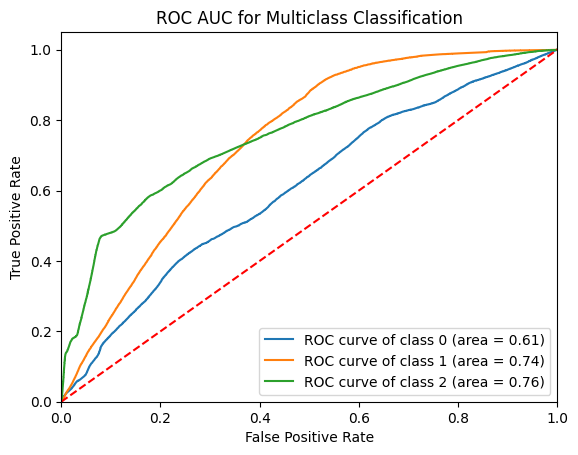

Do you want to save this model Y/N Y


In [98]:
model_validation(LogisticRegression(),xtrain, ytrain, xtest, ytest)

Confusion Matrix
 [[11075  5010  3297]
 [ 5220 31212  5606]
 [ 2801  6340 25211]]
Classification Matrix
               precision    recall  f1-score   support

         0.0       0.58      0.57      0.58     19382
         1.0       0.73      0.74      0.74     42038
         2.0       0.74      0.73      0.74     34352

    accuracy                           0.70     95772
   macro avg       0.68      0.68      0.68     95772
weighted avg       0.70      0.70      0.70     95772



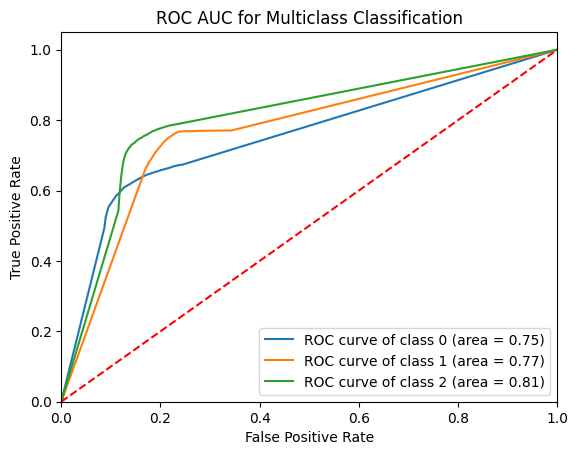

Do you want to save this model Y/N Y


In [99]:
model_validation(DecisionTreeClassifier(),xtrain,ytrain,xtest,ytest)

Confusion Matrix
 [[10432  5840  3110]
 [ 3101 34555  4382]
 [ 2053  7156 25143]]
Classification Matrix
               precision    recall  f1-score   support

         0.0       0.67      0.54      0.60     19382
         1.0       0.73      0.82      0.77     42038
         2.0       0.77      0.73      0.75     34352

    accuracy                           0.73     95772
   macro avg       0.72      0.70      0.71     95772
weighted avg       0.73      0.73      0.73     95772



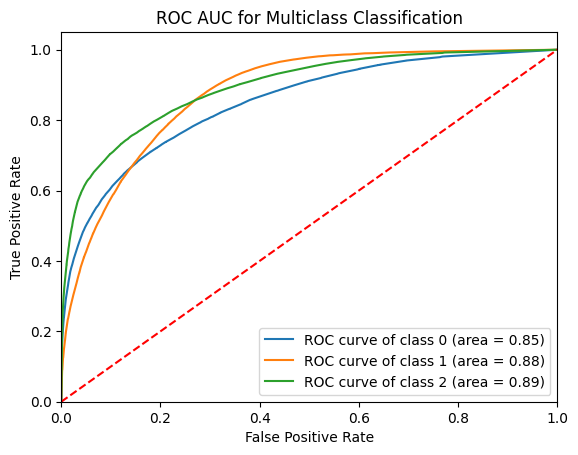

Do you want to save this model Y/N Y


In [100]:
model_validation(RandomForestClassifier(),xtrain,ytrain,xtest,ytest)

Confusion Matrix
 [[ 1700 11685  5997]
 [  507 36516  5015]
 [  728 12421 21203]]
Classification Matrix
               precision    recall  f1-score   support

         0.0       0.58      0.09      0.15     19382
         1.0       0.60      0.87      0.71     42038
         2.0       0.66      0.62      0.64     34352

    accuracy                           0.62     95772
   macro avg       0.61      0.52      0.50     95772
weighted avg       0.62      0.62      0.57     95772



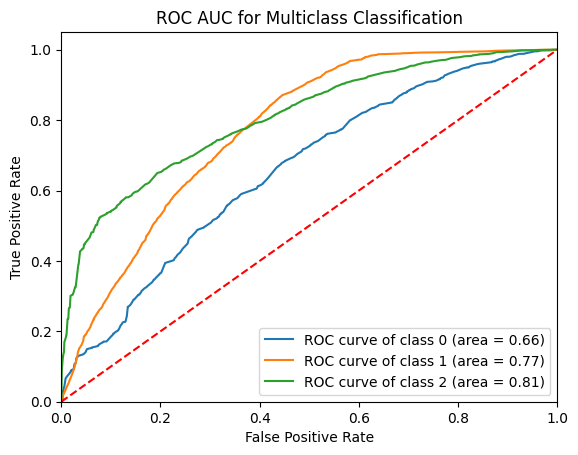

Do you want to save this model Y/N Y


In [101]:
model_validation(AdaBoostClassifier(),xtrain,ytrain,xtest,ytest)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(xtrain, ytrain)
print(f"Best Params: {grid_search.best_params_}")
print(grid_search.best_estimator_)
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


exception calling callback for <Future at 0x1cdbd92af50 state=finished raised TerminatedWorkerError>
Traceback (most recent call last):
  File "D:\Anaconda\Lib\site-packages\joblib\parallel.py", line 975, in retrieve
    self._output.extend(job.get(timeout=self.timeout))
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\site-packages\joblib\_parallel_backends.py", line 567, in wrap_future_result
    return future.result(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\concurrent\futures\_base.py", line 456, in result
    return self.__get_result()
           ^^^^^^^^^^^^^^^^^^^
  File "D:\Anaconda\Lib\concurrent\futures\_base.py", line 401, in __get_result
    raise self._exception
  File "D:\Anaconda\Lib\site-packages\joblib\externals\loky\_base.py", line 26, in _invoke_callbacks
    callback(self)
  File "D:\Anaconda\Lib\site-packages\joblib\parallel.py", line 385, in __call__
    self.parallel.dispatch_next()
  File "D:\A

In [ ]:
scorecard

## PCA for dimension reduction 

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=52)
pca.fit_transform(df_scaled)

In [ ]:
# Eigen values

pca.explained_variance_
plt.plot(range(1,53),pca.explained_variance_)
plt.xticks(range(1,53))
plt.tight_layout()
plt.show()

In [ ]:
# Cumulative explained variance ratio up to each components

np.cumsum(pca.explained_variance_ratio_)

In [ ]:
pca=PCA(n_components=30,random_state=42)
pca_data=pd.DataFrame(pca.fit_transform(df_scaled),columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8',
                                                        'PC9','PC10','PC11','PC12','PC13','PC14','PC15','PC16',
                                                        'PC17','PC18','PC19','PC20','PC21','PC22','PC23','PC24',
                                                        'PC25','PC26','PC27','PC28','PC29',
                                                            'PC30'])

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
xtrain_pca = pca.fit_transform(xtrain)
xtest_pca = pca.transform(xtest)

# Train the classifier on the PCA-transformed data
clf = RandomForestClassifier(random_state=42)
clf.fit(xtrain_pca, ytrain)

# Predict and evaluate
ypred = clf.predict(xtest_pca)
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("Classification Report:\n", classification_report(ytest, ypred))

# Optional: Visualize the explained variance to understand the number of components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [ ]:
pca_data

## LDA 

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,P

lda=LinearDiscriminantAnalysis()
df_lda=lda.fit_transform(df_scaled,df_scaled['IncidentGrade'])


In [ ]:
lda.explained_variance_ratio_

In [ ]:
df_lda=pd.DataFrame(df_lda,columns=['LD1','LD2'])

In [ ]:
df_lda

In [ ]:
sns.scatterplot(x=df_lda['LD1'],y=df_lda['LD2'],hue=df_scaled['IncidentGrade'])

## Modelling 

In [ ]:
x=pd.DataFrame(df_lda['LD1'])
y=df_scaled['IncidentGrade']

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=1)

In [ ]:
mod = []
accu = []
prec = []
rec = []
f1 = []
kappa = []

def model_validation(model, xtrain, ytrain, xtest, ytest):
    m = model
    m.fit(xtrain, ytrain)
    pred_h = m.predict(xtest)
    
    # Predict probabilities for ROC AUC calculation
    if hasattr(m, "predict_proba"):
        pred_s = m.predict_proba(xtest)
    else:
        pred_s = m.decision_function(xtest)
    
    print('Confusion Matrix\n', confusion_matrix(ytest, pred_h))
    print('Classification Matrix\n', classification_report(ytest, pred_h))
    
    # Binarize the output for multiclass ROC AUC
    ytest_binarized = label_binarize(ytest, classes=np.unique(ytest))
    
    # Compute ROC curve and ROC area for each class
    n_classes = ytest_binarized.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(ytest_binarized[:, i], pred_s[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC for Multiclass Classification')
    plt.legend(loc="lower right")
    plt.show()

    response = input('Do you want to save this model Y/N')
    if response.lower() == 'y':
        mod.append(str(model))
        accu.append(accuracy_score(ytest, pred_h))
        rec.append(recall_score(ytest, pred_h, average='macro'))  # Use macro average for multiclass
        prec.append(precision_score(ytest, pred_h, average='macro'))  # Use macro average for multiclass
        f1.append(f1_score(ytest, pred_h, average='macro'))  # Use macro average for multiclass
        kappa.append(cohen_kappa_score(ytest, pred_h))

        global scorecard
        scorecard = pd.DataFrame({'Model': mod,
                                  'Accuracy': accu,
                                  'Precision': prec,
                                  'Recall': rec,
                                  'F1 Score': f1,
                                  'Cohen Kappa': kappa})
    else:
        return


In [ ]:
model_validation(DecisionTreeClassifier(),xtrain,ytrain,xtest,ytest)

In [ ]:
model_validation(RandomForestClassifier(),xtrain,ytrain,xtest,ytest)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Fit the model
rf_random.fit(xtrain, ytrain)

# Best parameters
print("Best Parameters:", rf_random.best_params_)

# Predict with the best model
best_rf = rf_random.best_estimator_
predictions = best_rf.predict(xtest)

# Evaluate
print(confusion_matrix(ytest, predictions))
print(classification_report(ytest, predictions))